<a href="https://colab.research.google.com/github/feicapdevilalab/MeCPMG-Fitting/blob/main/CPMG_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from pandas import DataFrame
from scipy.optimize import curve_fit
from math import ceil
import re
import matplotlib.pyplot as plt

# User-editable values
sample_name = '20200315_SqrR_tetra_800MHz_ILVAM_MeCPMG_pH5o1_40C'
fixed_tau = 0.0017 # seconds
noise = 1000


def fitFunc(nu,R2,Rex):
    t=fixed_tau
    return R2+Rex*(1-2*t*nu*np.tanh(1/(2*t*nu)))
def fitFreeTau(nu, t, R2,Rex):
    return R2+Rex*(1-2*t*nu*np.tanh(1/(2*t*nu)))

one_letter ={'VAL':'V', 'ILE':'I', 'LEU':'L', 'GLU':'E', 'GLN':'Q', \
'ASP':'D', 'ASN':'N', 'HIS':'H', 'TRP':'W', 'PHE':'F', 'TYR':'Y',    \
'ARG':'R', 'LYS':'K', 'SER':'S', 'THR':'T', 'MET':'M', 'ALA':'A',    \
'GLY':'G', 'PRO':'P', 'CYS':'C'}

three_letter = dict([[v,k] for k,v in one_letter.items()])

def format_label(orig):
    orig = orig.strip()
    res, _ = orig.split('-')  # ignoramos el hidrógeno
    # Modified regex to handle cases like 'LX2CG' where an extra letter might appear between the AA code and residue number
    # Group 1: One-letter AA code (e.g., 'L')
    # Group 2: Optional single letter modifier (e.g., 'X' in 'LX2CG', or empty string)
    # Group 3: Residue number (e.g., '2')
    # Group 4: Atom name (e.g., 'CG')
    match = re.match(r'^([A-Z])([A-Z]?)(\d+)([A-Z0-9]+)$', res)
    if not match:
        raise ValueError(f"No se pudo parsear: '{res}' desde '{orig}'")

    one_letter_code = match.groups()[0]
    optional_modifier = match.groups()[1]
    resi = match.groups()[2]
    atom_name = optional_modifier + match.groups()[3] # Combine optional modifier with atom name

    resn = three_letter[one_letter_code]

    return resi, resn, atom_name

def name2ncyc(col_name):
    if '/' in col_name:
        filename,ncyc = col_name.split('/')
        return ncyc
    else:
        return col_name

def name2Hz(col_name):
    if '/' in col_name:
        filename,ncyc = col_name.split('/')
        return 25*int(ncyc)
    else:
        return col_name

def parsepeaktable(filepath):
    df0 = pd.read_table(filepath, delim_whitespace=True,index_col='Assignment')
    column_names = list(df0.columns.values)
    filtered_column_names = []
    ncyc_list = []
    for col in column_names:
        if col not in ['T-decay','SD']:
            filename,ncyc = col.split('/')
            if int(ncyc) > 0 or ncyc not in ncyc_list:
                ncyc_list.append(ncyc)
                filtered_column_names.append(col)
    df1 = df0[filtered_column_names]
    col_names_in_Hz = [name2Hz(col) for col in filtered_column_names]
    df1.columns = col_names_in_Hz
    return df1

def calcR2eff(heightsDF):
    # Get the smallest frequency column, which is considered Io
    io_col = np.sort(heightsDF.columns.values)[0]

    # Extract Io values (intensities at the smallest frequency) for each peak
    Io_series = heightsDF[io_col]*2

    # Create a DataFrame with only the intensities (I) for other frequencies
    I_df = heightsDF.drop(columns=[io_col])

    # Calculate R2eff = -25 * ln(I / Io)
    # Divide each column of I_df by the corresponding Io_series value, aligned by index
    R2effs = -25 * np.log(I_df.div(Io_series, axis=0))
    return R2effs

def fitCurves(R2effs):
    assignments = R2effs.index
    all_fits = pd.DataFrame(columns=['R2','R2_err','Rex','Rex_err'],index=assignments)
    for ass in assignments:
        R2eff_row = R2effs.loc[ass] # This is a pandas Series

        # Filter out non-finite (NaN, inf, -inf) values from R2eff_row
        # This results in a filtered Series where the index (frequencies) and values (R2effs) are aligned.
        R2eff_row_filtered_series = R2eff_row[np.isfinite(R2eff_row)]

        R2efflist_filtered = R2eff_row_filtered_series.values
        freqs_filtered = R2eff_row_filtered_series.index.values # Get frequencies directly from the filtered series

        # Check if there's enough data points after filtering
        if len(R2efflist_filtered) < 2: # curve_fit needs at least 2 data points for a fit
            print(f"Warning: Not enough valid data points for assignment '{ass}' after filtering non-finite values. Skipping fit.")
            all_fits.loc[ass] = [np.nan, np.nan, np.nan, np.nan]
            continue

        try:
            fitParams, fitCovariances = curve_fit(fitFunc, freqs_filtered, R2efflist_filtered, bounds=([0.,0.],[100,100]))
            R2,Rex = fitParams
            R2_err,Rex_err = np.sqrt(np.diag(fitCovariances))
            all_fits.loc[ass]=[R2,R2_err,Rex,Rex_err]
        except RuntimeError as e:
            print(f"Warning: Could not fit curve for assignment '{ass}'. Error: {e}")
            all_fits.loc[ass] = [np.nan, np.nan, np.nan, np.nan]
        except ValueError as e:
            print(f"Warning: ValueError during fit for assignment '{ass}'. Error: {e}")
            all_fits.loc[ass] = [np.nan, np.nan, np.nan, np.nan]

    coloring = pd.DataFrame(columns=['number','letter', 'type' ,'Rex'],index=assignments)
    for i, ass in enumerate(assignments):
        # Handle cases where all_fits might have NaN due to failed fits
        if pd.isna(all_fits['Rex'][i]):
            coloring.loc[ass]=[format_label(ass)[0], format_label(ass)[1],format_label(ass)[2],np.nan]
        else:
            coloring.loc[ass]=[format_label(ass)[0], format_label(ass)[1],format_label(ass)[2],all_fits['Rex'][i]]
    return all_fits

def plotfakecurve(assignment,R2effs,ax):
    freqs = R2effs.columns.values
    R2efflist = R2effs.loc[assignment].values.tolist()
    ax.plot(freqs,R2efflist,'w')
    plt.setp(ax.get_xticklabels(),rotation='vertical')

def plotCurves(R2effs,all_fits):
    freqs = R2effs.columns.values # Frequencies are common for all plots

    # Concatenate R2effs and all_fits to iterate over each peak (row) individually
    # This handles duplicate assignment names by treating each row as a distinct entry.
    combined_data = pd.concat([R2effs, all_fits], axis=1)

    rows_per_page = 5
    cols_per_page = 4
    num_plots_per_page = rows_per_page * cols_per_page

    num_total_plots = len(combined_data)
    pages = ceil(num_total_plots / num_plots_per_page)

    fig = None
    axes = None
    row_idx = 0
    col_idx = 0
    page_num = 0

    for idx, (original_assignment, row_series) in enumerate(combined_data.iterrows()):
        # Initialize new figure/axes for a new page if necessary
        if idx % num_plots_per_page == 0:
            if fig is not None: # Save previous page if it exists
                big_ax = fig.add_subplot(111)
                big_ax.set_facecolor("none") # set_fc is deprecated, use set_facecolor
                big_ax.tick_params(labelcolor='none', top='off', bottom='off', left='off', right='off')
                big_ax.spines['top'].set_color('none')
                big_ax.spines['bottom'].set_color('none')
                big_ax.spines['left'].set_color('none')
                big_ax.spines['right'].set_color('none')
                big_ax.set_title(sample_name)
                plt.ylabel('$R2_{eff}$' + ' (Hz)')
                plt.xlabel(r'$\nu_{cp}$' + '(Hz)', labelpad=20)
                plt.savefig('%s_curves_fixedtau_%d.pdf' % (sample_name, page_num))
                plt.show()

            fig, axes = plt.subplots(rows_per_page, cols_per_page, sharex=True, sharey=True)
            fig.set_size_inches(18, 19.5)
            fig.subplots_adjust(wspace=0.1, hspace=0.1)
            row_idx = 0
            col_idx = 0
            page_num = idx // num_plots_per_page

        # Extract data for the current peak
        ass = original_assignment # The assignment string for this specific peak

        # R2eff values are the columns corresponding to frequencies
        R2efflist = row_series[freqs].values.tolist()

        # Fit parameters are the remaining columns
        R2_val, R2_err_val, Rex_val, Rex_err_val = row_series[['R2', 'R2_err', 'Rex', 'Rex_err']].values

        # Ensure R2 and Rex are floats for formatting, handling potential non-numeric values
        try:
            R2 = float(R2_val)
        except (ValueError, TypeError):
            R2 = np.nan
        try:
            Rex = float(Rex_val)
        except (ValueError, TypeError):
            Rex = np.nan

        Tau_ms = fixed_tau * 1000
        exp1 = r'$R_{2} = %.1f$' % R2 + ' Hz'
        exp2 = r'$R_{ex} = %.1f$' % Rex + ' Hz'
        exp3 = r'$tau = %.1f ms$' % Tau_ms

        ax = axes[row_idx, col_idx]
        ax.plot(freqs, R2efflist, '.')
        # Only plot fit if R2 and Rex are not NaN
        if not (pd.isna(R2) or pd.isna(Rex)):
            ax.plot(freqs, fitFunc(freqs, R2, Rex))

        ax.axis(ymax=5)
        ax.axis(ymin=0)
        plt.setp(ax.get_xticklabels(), rotation='vertical')
        ax.annotate(ass + ',' + exp1 + '\n' + exp2 + ',' + exp3, xy=(10, 50), xycoords='axes points',
                    horizontalalignment='left', verticalalignment='top')

        col_idx += 1
        if col_idx >= cols_per_page:
            col_idx = 0
            row_idx += 1

    # After the loop, save the last page if it has any plots
    if fig is not None:
        # Fill remaining subplots on the last page with blanks
        while row_idx < rows_per_page:
            while col_idx < cols_per_page:
                axes[row_idx, col_idx].set_visible(False)
                col_idx += 1
            col_idx = 0
            row_idx += 1

        big_ax = fig.add_subplot(111)
        big_ax.set_facecolor('none')
        big_ax.tick_params(labelcolor='none', top='off', bottom='off', left='off', right='off')
        big_ax.spines['top'].set_color('none')
        big_ax.spines['bottom'].set_color('none')
        big_ax.spines['left'].set_color('none')
        big_ax.spines['right'].set_color('none')
        big_ax.set_title(sample_name)
        plt.ylabel('$R2_{eff}$' + ' (Hz)')
        plt.xlabel(r'$\nu_{cp}$' + '(Hz)', labelpad=20)
        plt.savefig('%s_curves_fixedtau_%d.pdf' % (sample_name, page_num))
        plt.show()

def Rexbarplot(all_fits):
    # Generate unique labels for assignments, handling duplicates
    unique_assignments_list = []
    counts = {}
    for ass in all_fits.index:
        counts[ass] = counts.get(ass, 0) + 1
        if counts[ass] > 1:
            unique_assignments_list.append(f'{ass}_{counts[ass]}')
        else:
            unique_assignments_list.append(ass)

    Rexvalues = all_fits['Rex'].values
    Rexerrors = all_fits['Rex_err'].values

    fig, ax = plt.subplots(figsize=(20,5))
    h = ax.bar(np.arange(len(unique_assignments_list)),
                  Rexvalues,
                  color='r',
                  yerr=Rexerrors,
                  capsize=5) # Added capsize for error bars

    plt.subplots_adjust(bottom=0.3)
    xticks_pos = [0.5*patch.get_width() + patch.get_xy()[0] for patch in h]
    ax.set_xticks(xticks_pos)
    ax.set_xticklabels(unique_assignments_list, ha='right', rotation=45)

    ax.set_ylabel('$R_{ex}$' + ' (Hz)')
    ax.set_title(sample_name)
    plt.show()

def plot_raw_signal(dataset, resname):
  res_data = dataset.loc[resname]
  signal = res_data.values
  plt.figure()
  plt.plot(res_data.index, signal, 'b.')
  plt.ylabel('Intensity (a.u.)')
  plt.xlabel('Frequency (Hz)')
  plt.title('Raw data')
  plt.show()

In [2]:
DF_600_red = parsepeaktable('/content/20200227_SqrR_red_ILVAM_MeCPMG_pH5o1_40C_rep_20260206_peak_heights.txt')
DF_800_red = parsepeaktable('/content/20200227_ILVAM_SqrRC9S_800MHz_CH3cpmg_red_pH5o1_40C_peak_heights.txt')
DF_800_tetra = parsepeaktable('/content/20200303_ILVAM_SqrRC9S_CH3cpmg_tetra_pH5o1_40C_800MHz_peak_heights.txt')
DF_600_tetra = parsepeaktable('/content/20200315_SqrR_tetra_ILVAM_MeCPMG_pH5o1_40C_rep_20260206_peak_heights.txt')

/tmp/ipykernel_11059/362722824.py:64: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df0 = pd.read_table(filepath, delim_whitespace=True,index_col='Assignment')
/tmp/ipykernel_11059/362722824.py:64: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df0 = pd.read_table(filepath, delim_whitespace=True,index_col='Assignment')
/tmp/ipykernel_11059/362722824.py:64: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df0 = pd.read_table(filepath, delim_whitespace=True,index_col='Assignment')
/tmp/ipykernel_11059/362722824.py:64: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df0 = pd.read_table(filepath, delim_

In [3]:
R2effs_600_red = calcR2eff(DF_600_red)
R2effs_600_tetra = calcR2eff(DF_600_tetra)
R2effs_800_red = calcR2eff(DF_800_red)
R2effs_800_tetra = calcR2eff(DF_800_tetra)

In [4]:
all_fits_600_red = fitCurves(R2effs_600_red)
all_fits_600_tetra = fitCurves(R2effs_600_tetra)
all_fits_800_red = fitCurves(R2effs_800_red)
all_fits_800_tetra = fitCurves(R2effs_800_tetra)

/tmp/ipykernel_11059/362722824.py:128: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if pd.isna(all_fits['Rex'][i]):
/tmp/ipykernel_11059/362722824.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coloring.loc[ass]=[format_label(ass)[0], format_label(ass)[1],format_label(ass)[2],all_fits['Rex'][i]]


/tmp/ipykernel_11059/362722824.py:128: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if pd.isna(all_fits['Rex'][i]):
/tmp/ipykernel_11059/362722824.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coloring.loc[ass]=[format_label(ass)[0], format_label(ass)[1],format_label(ass)[2],all_fits['Rex'][i]]


/tmp/ipykernel_11059/362722824.py:128: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if pd.isna(all_fits['Rex'][i]):
/tmp/ipykernel_11059/362722824.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coloring.loc[ass]=[format_label(ass)[0], format_label(ass)[1],format_label(ass)[2],all_fits['Rex'][i]]
/tmp/ipykernel_11059/362722824.py:128: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if pd.isna(all_fits['Rex'][i]):
/tmp/ipykernel

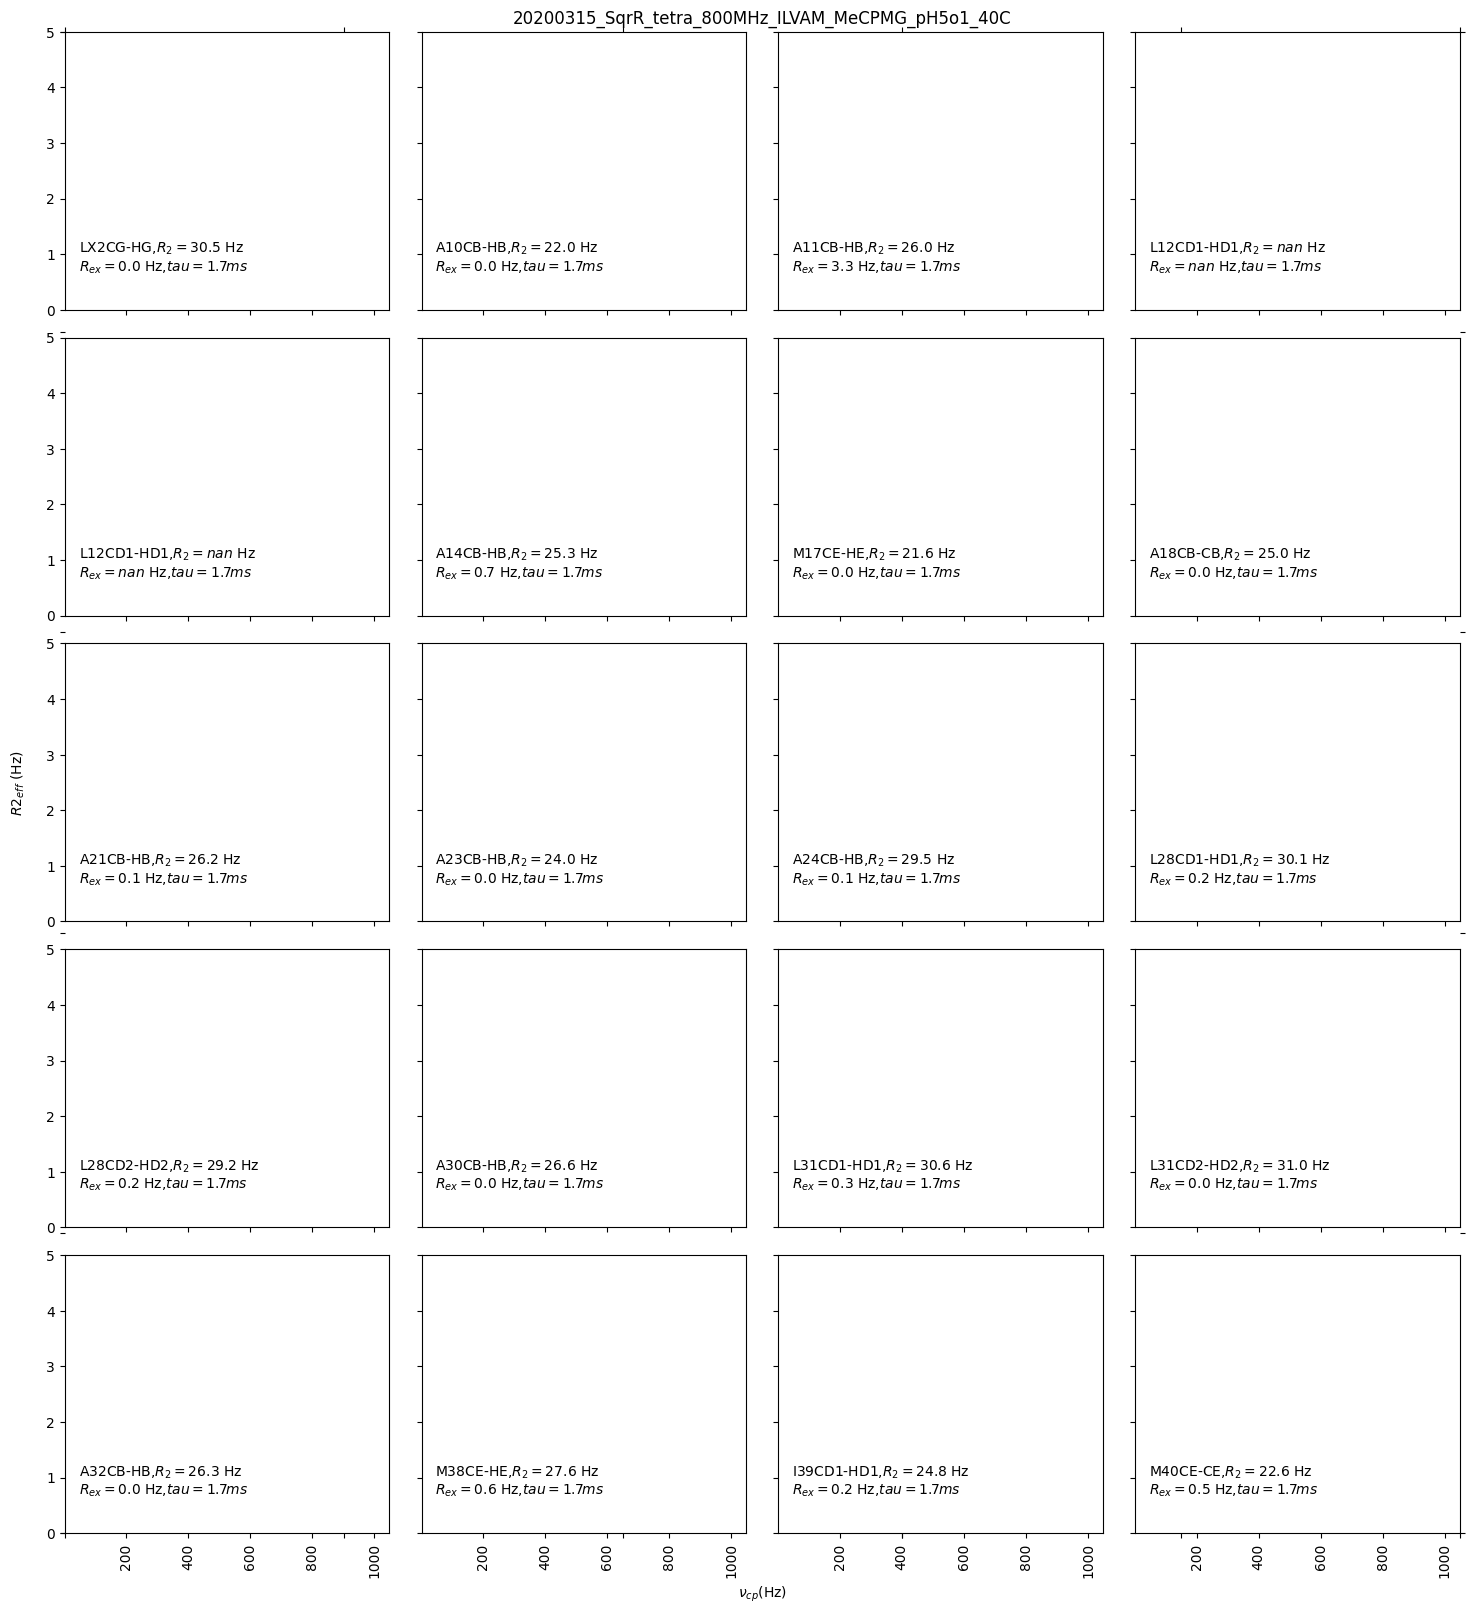

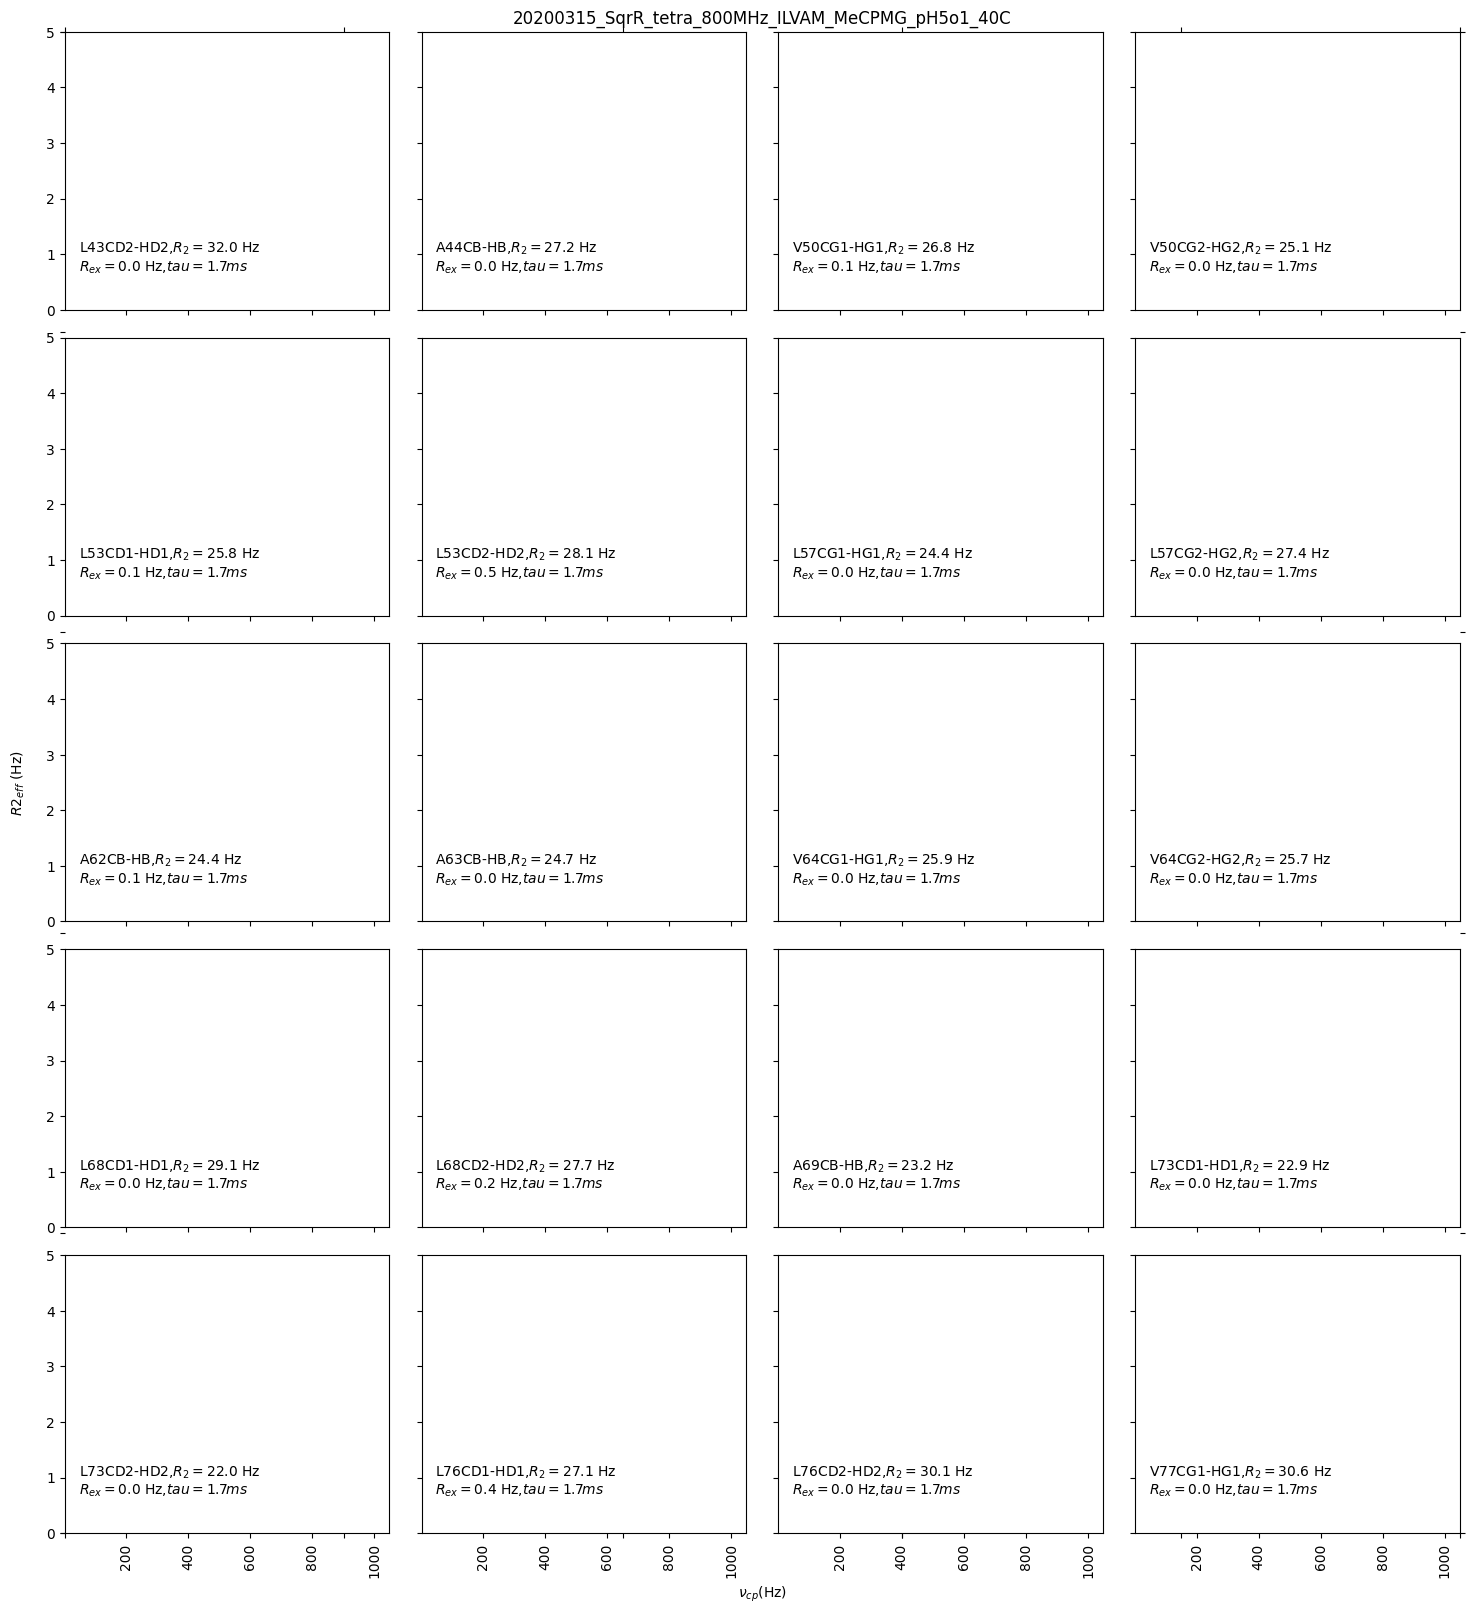

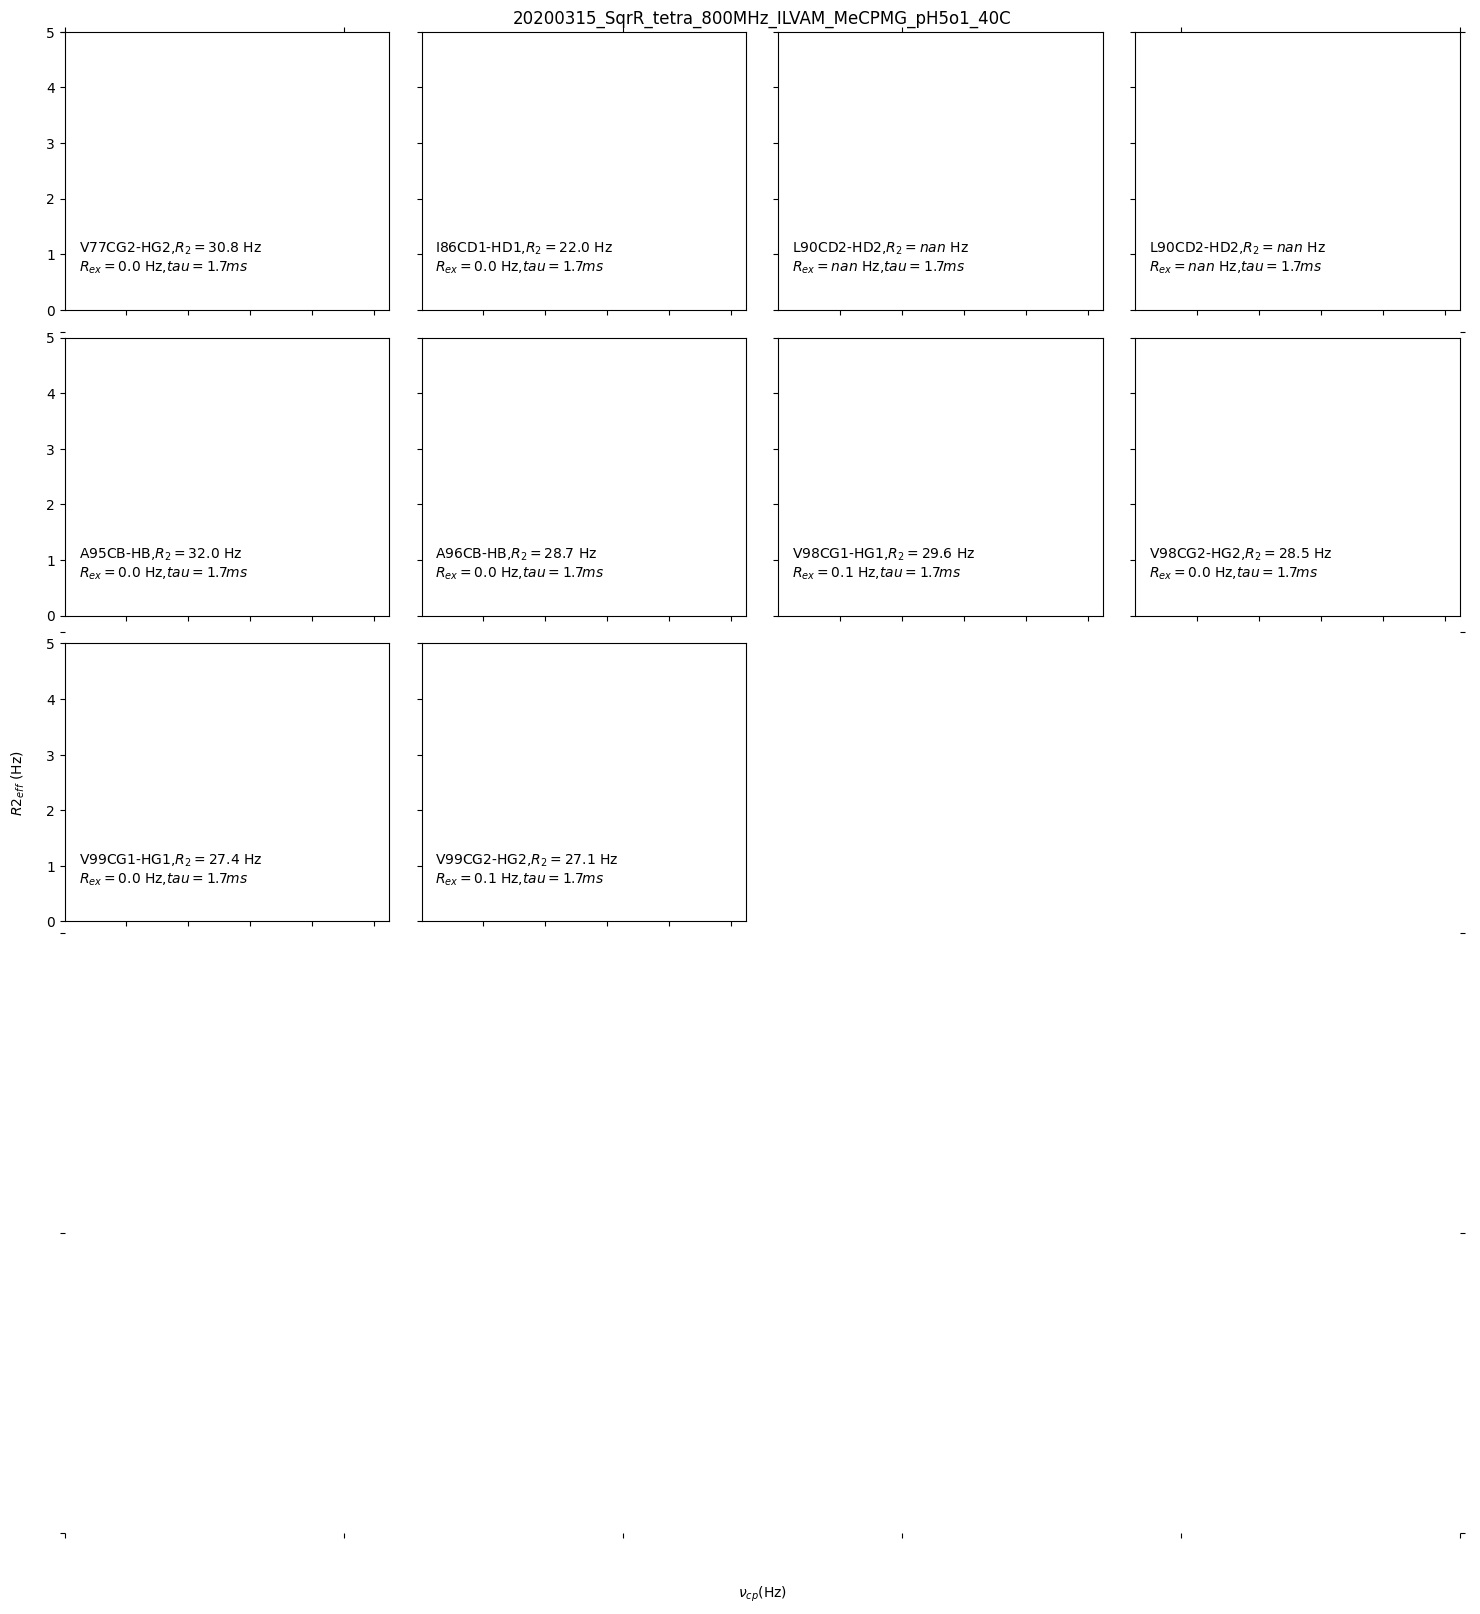

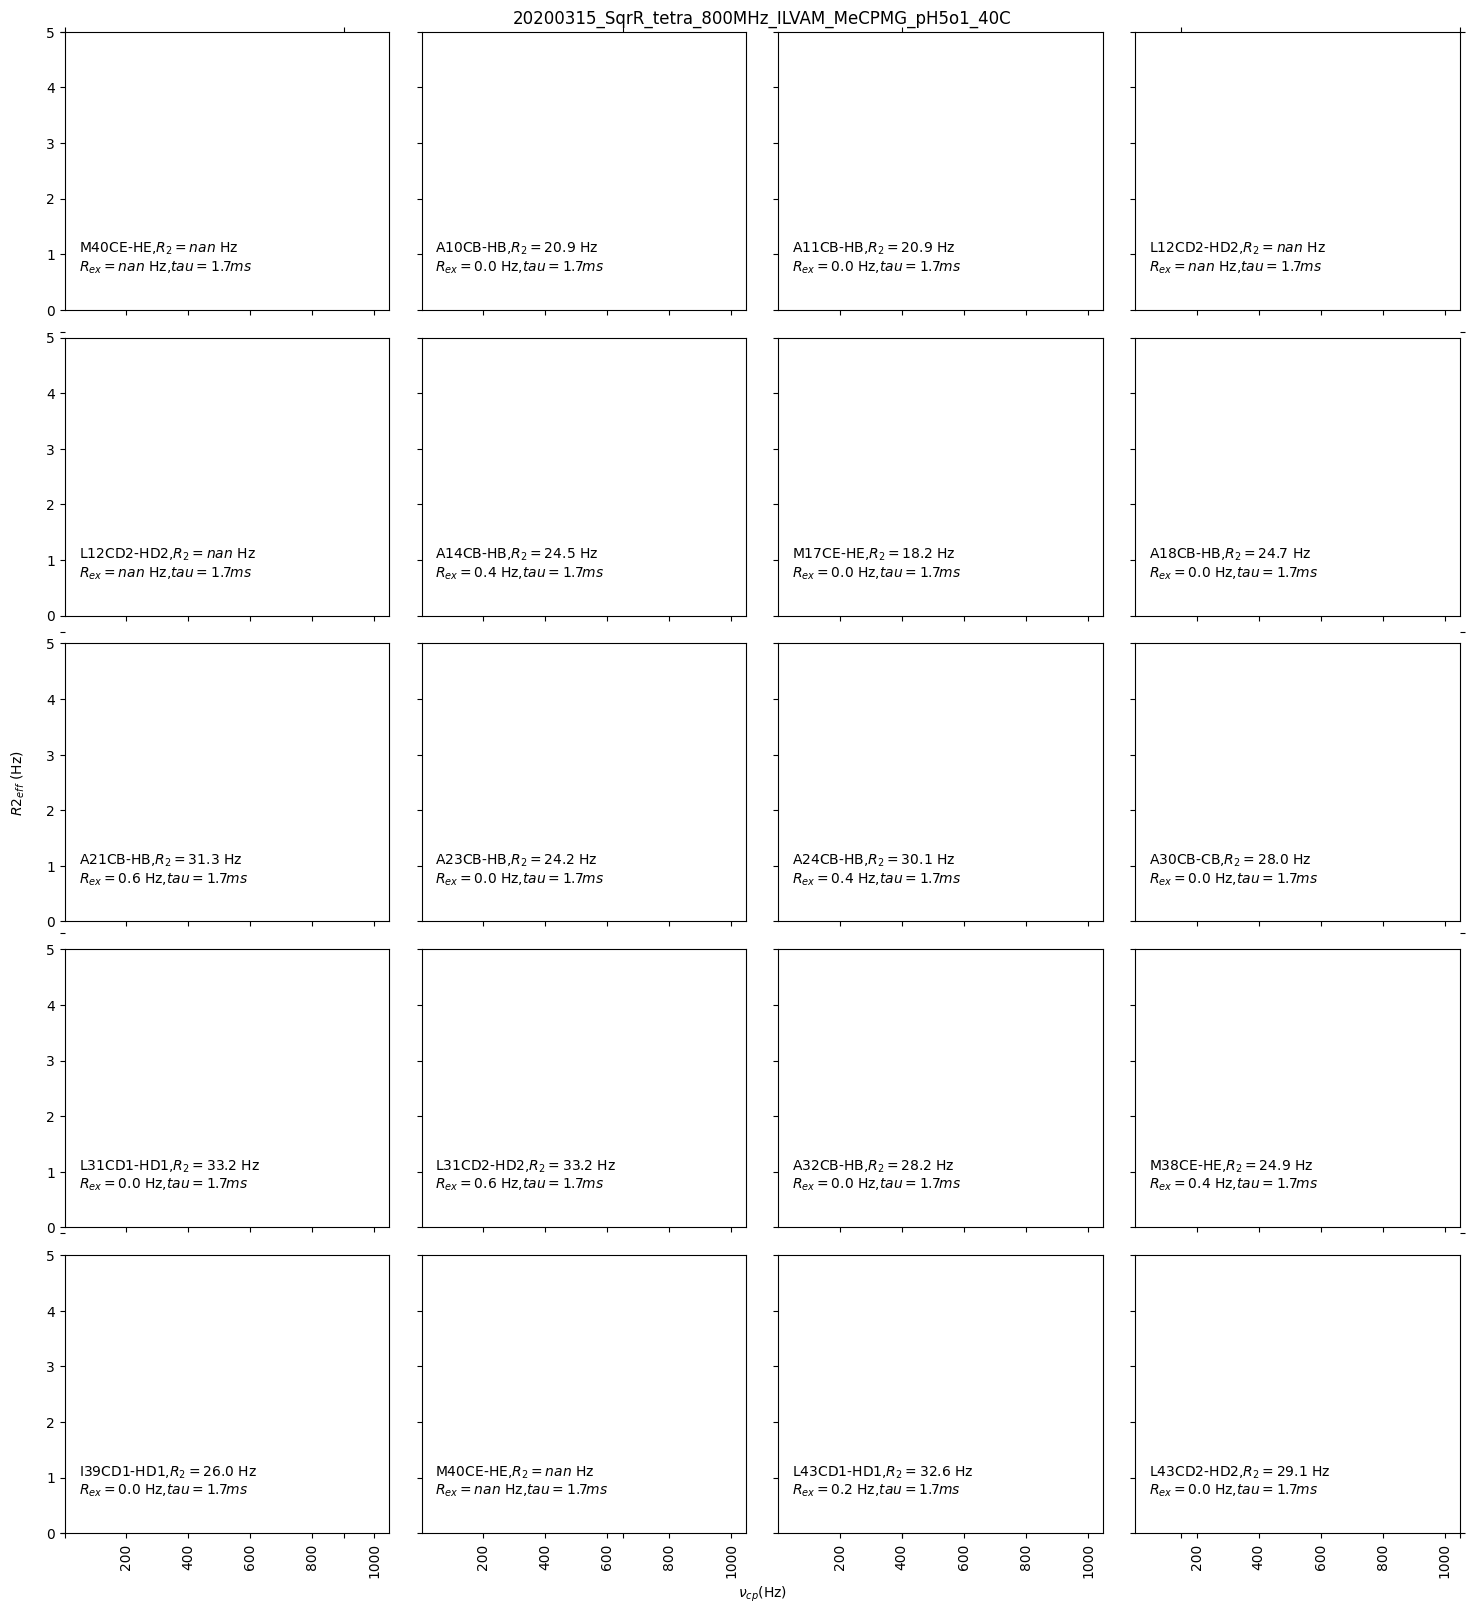

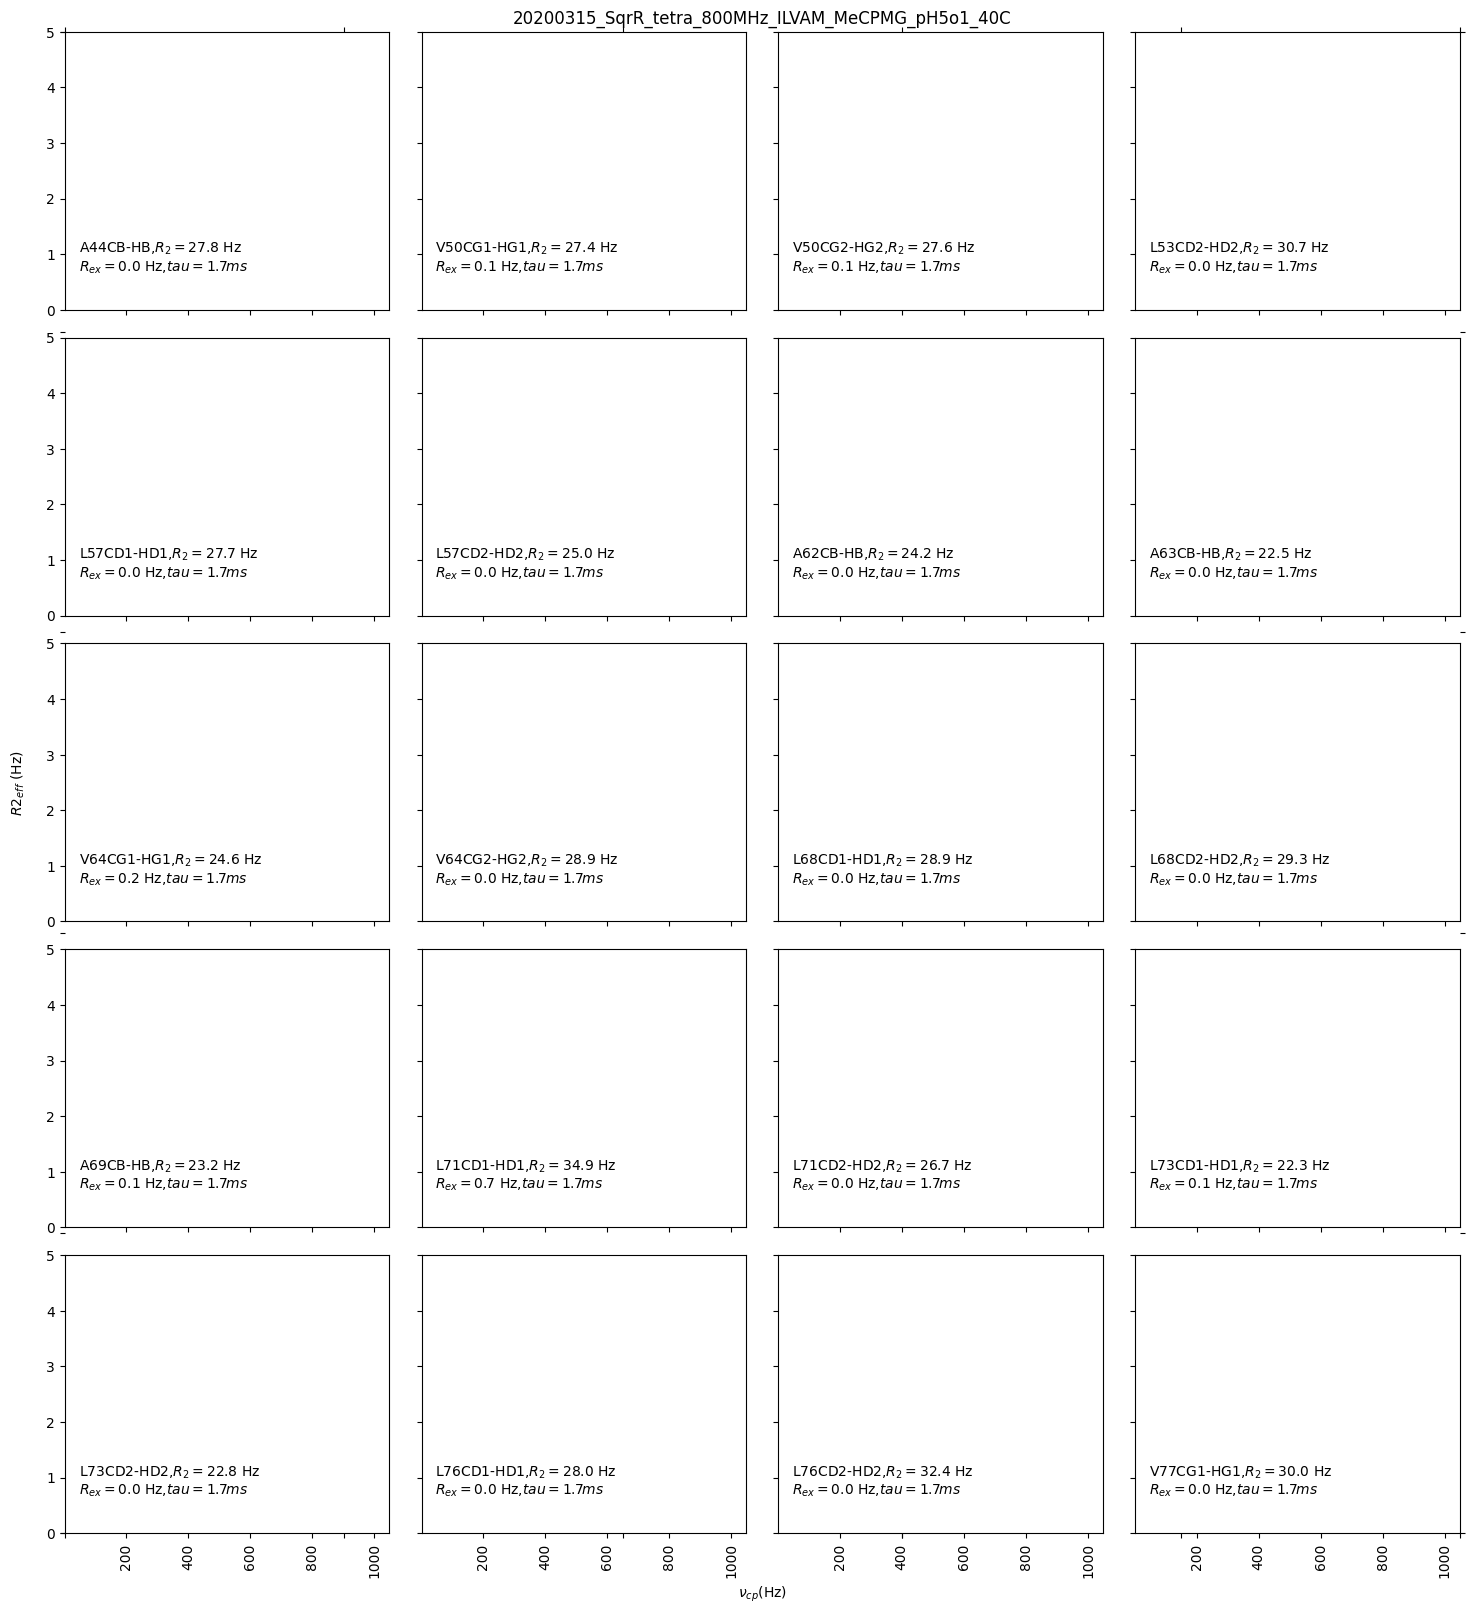

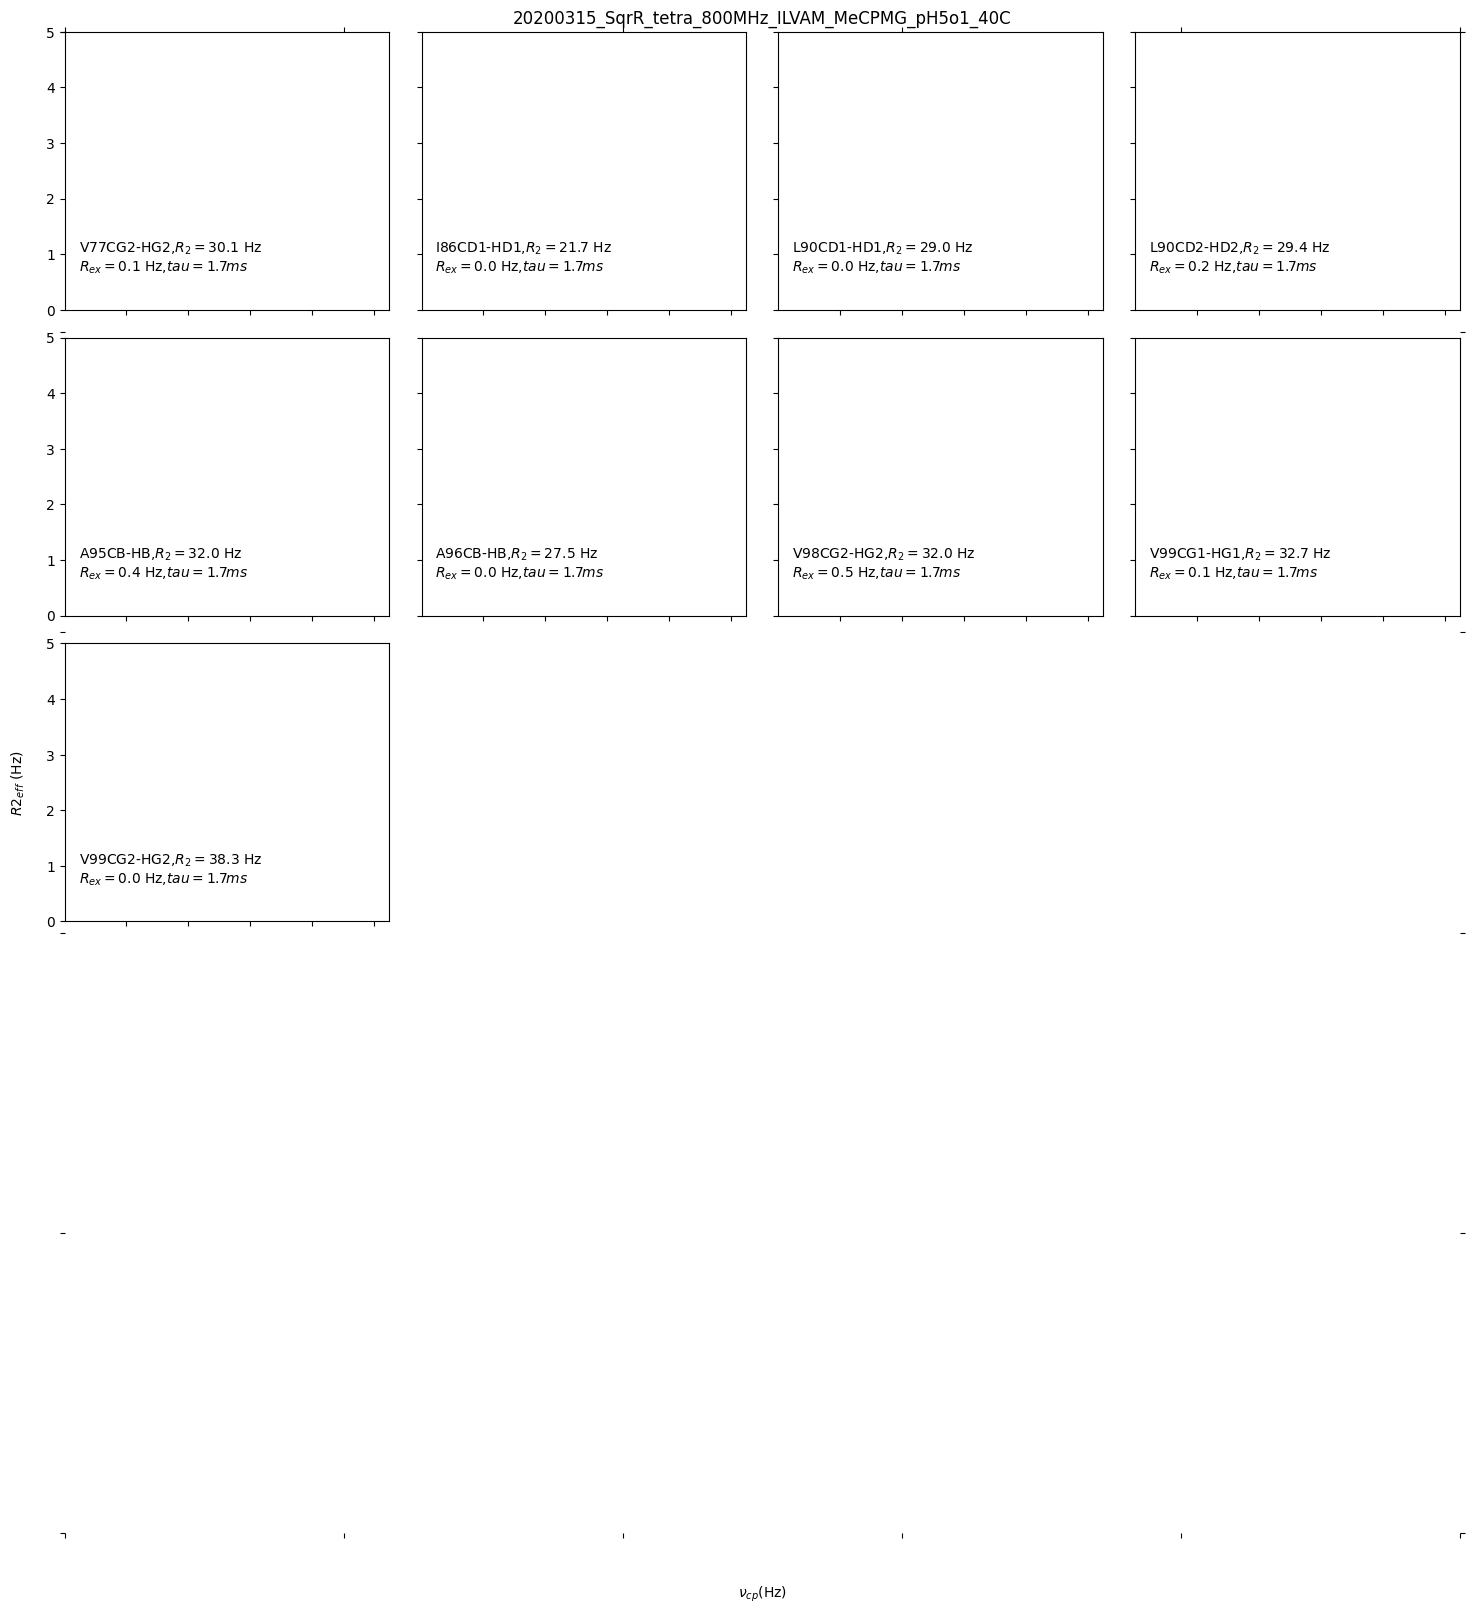

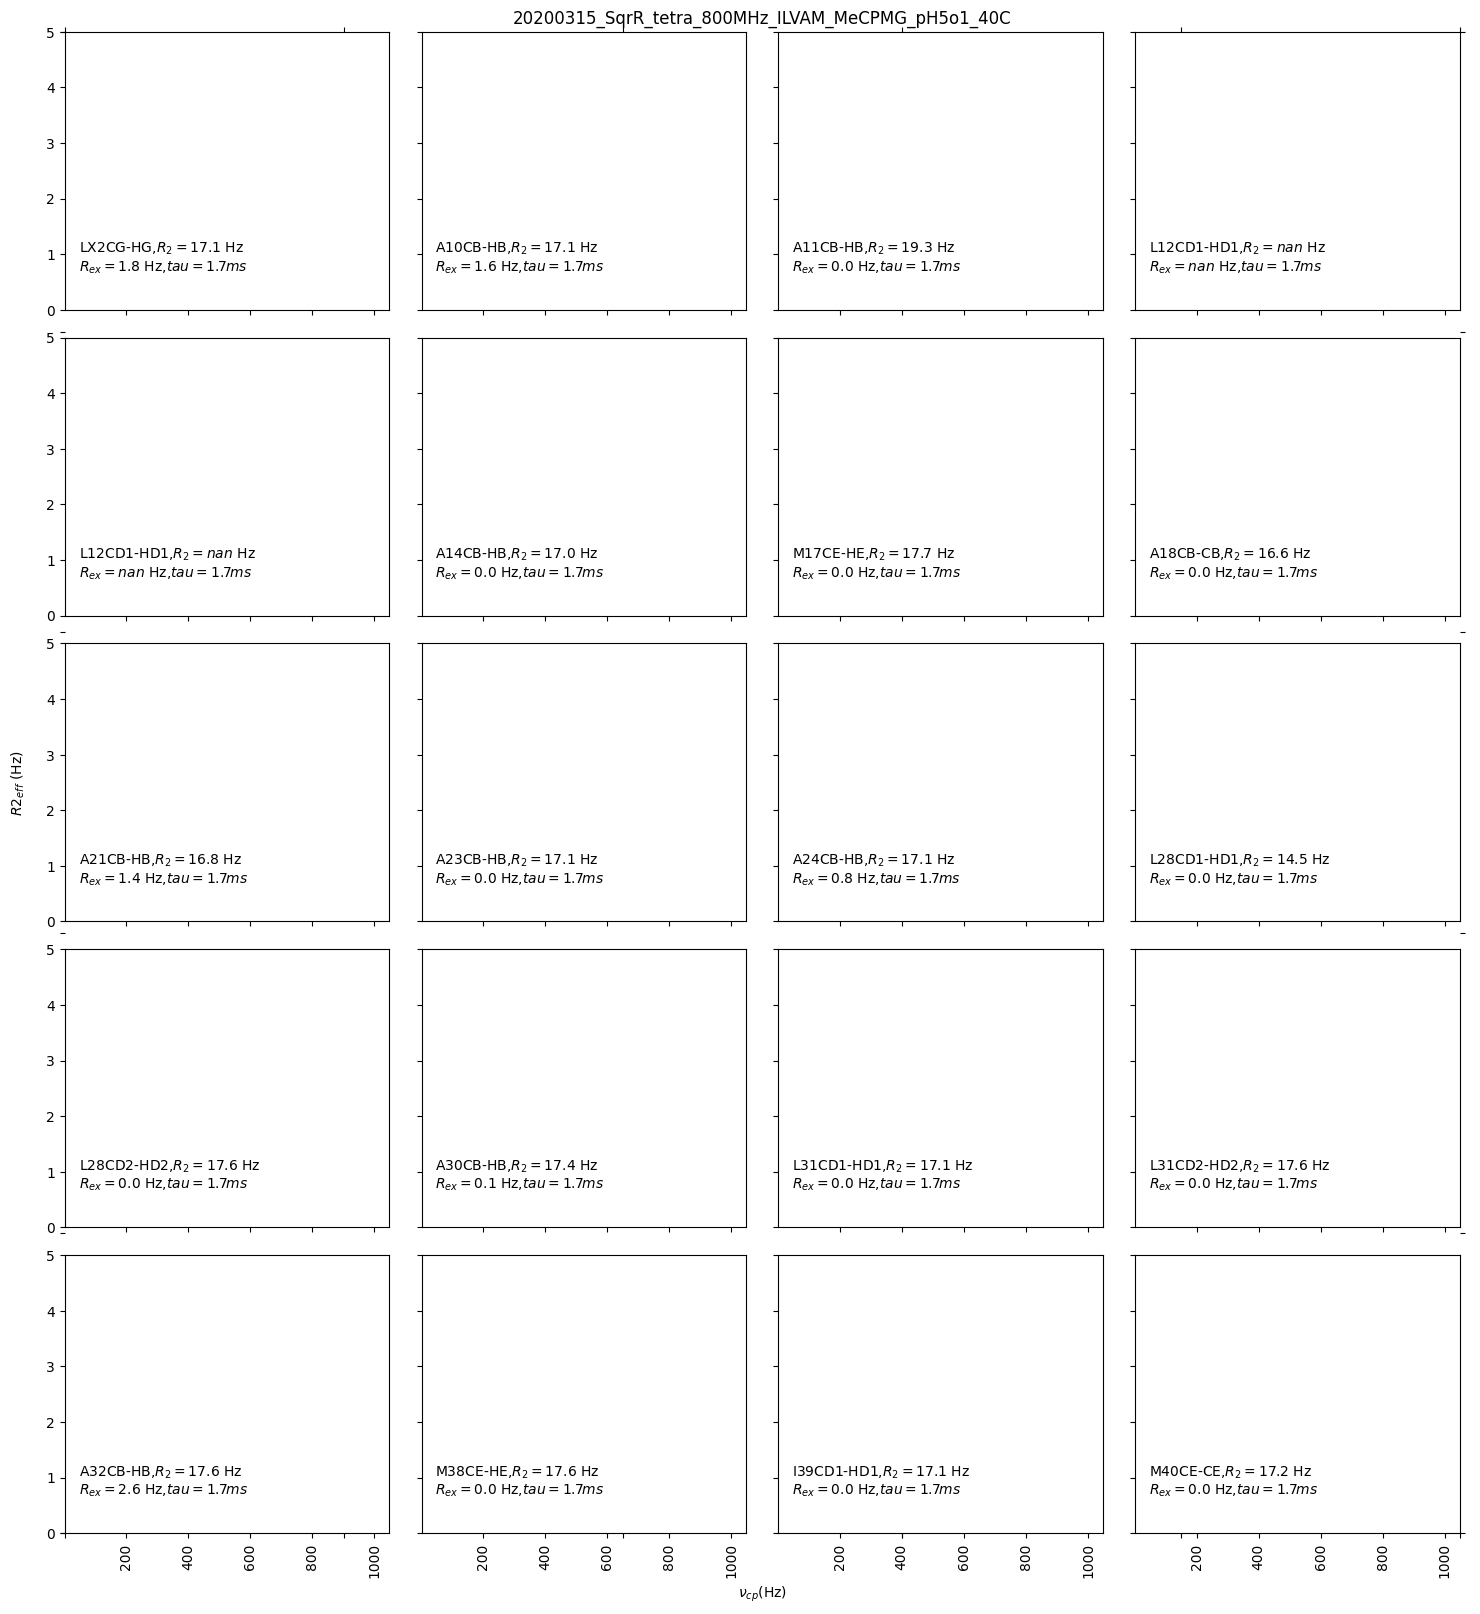

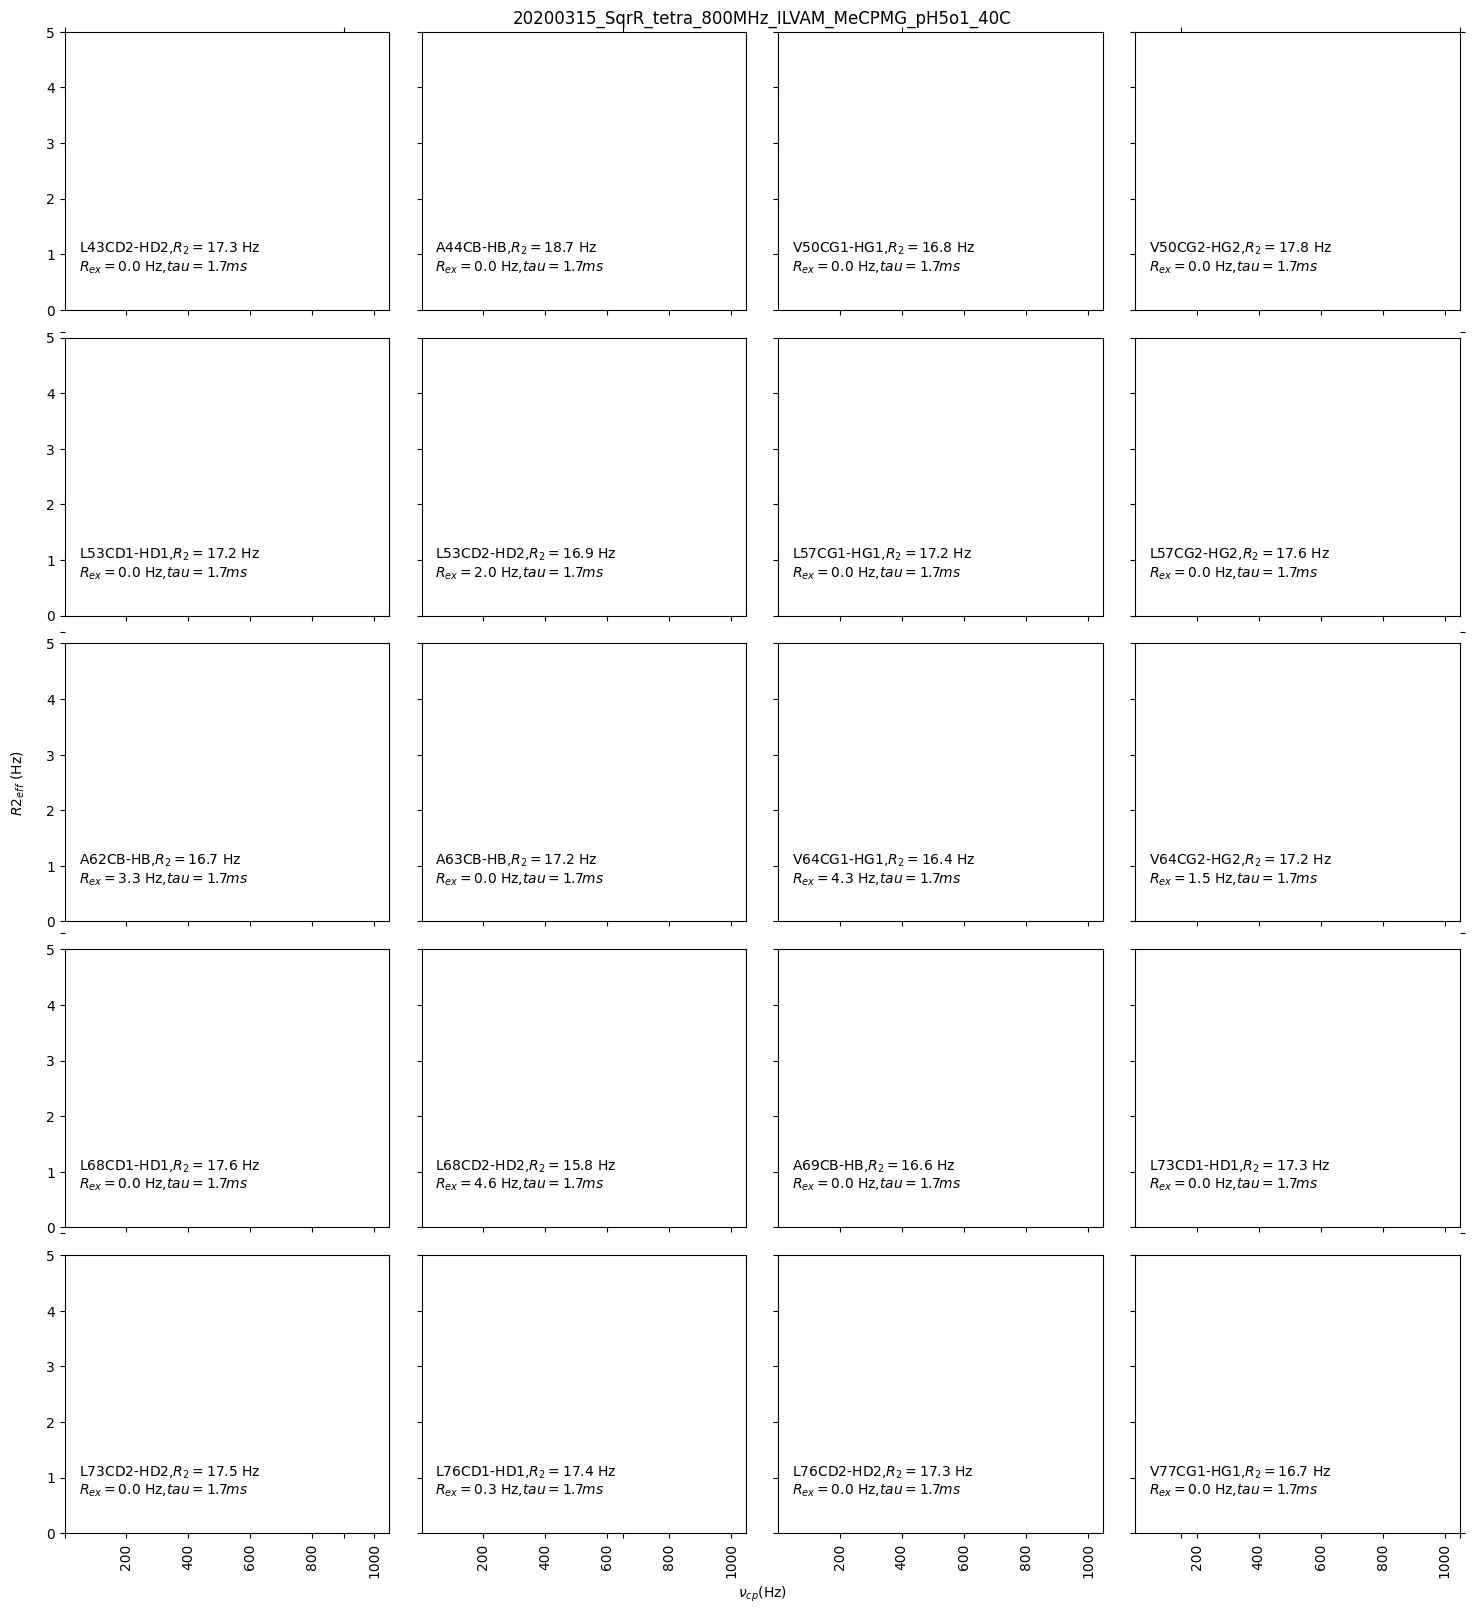

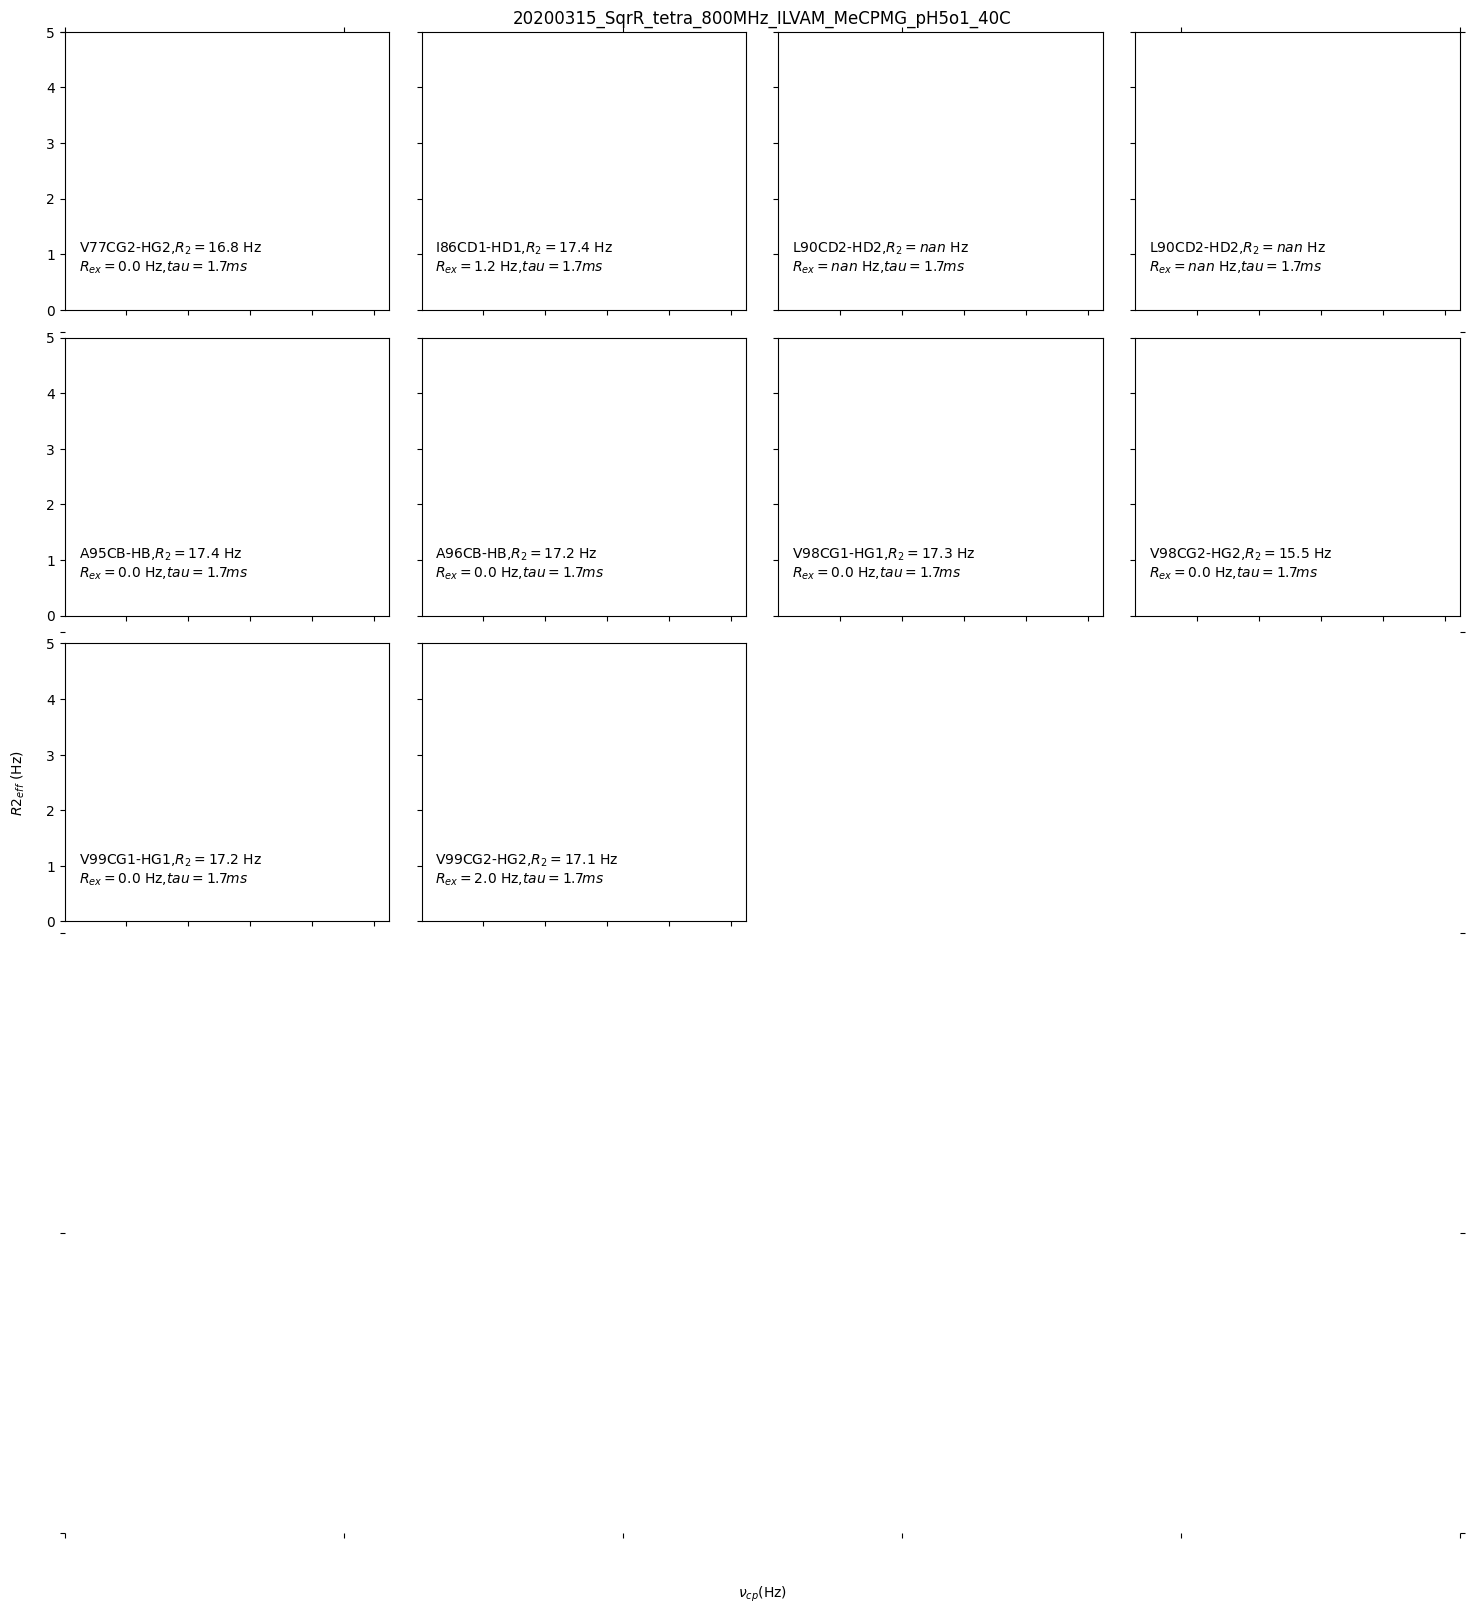

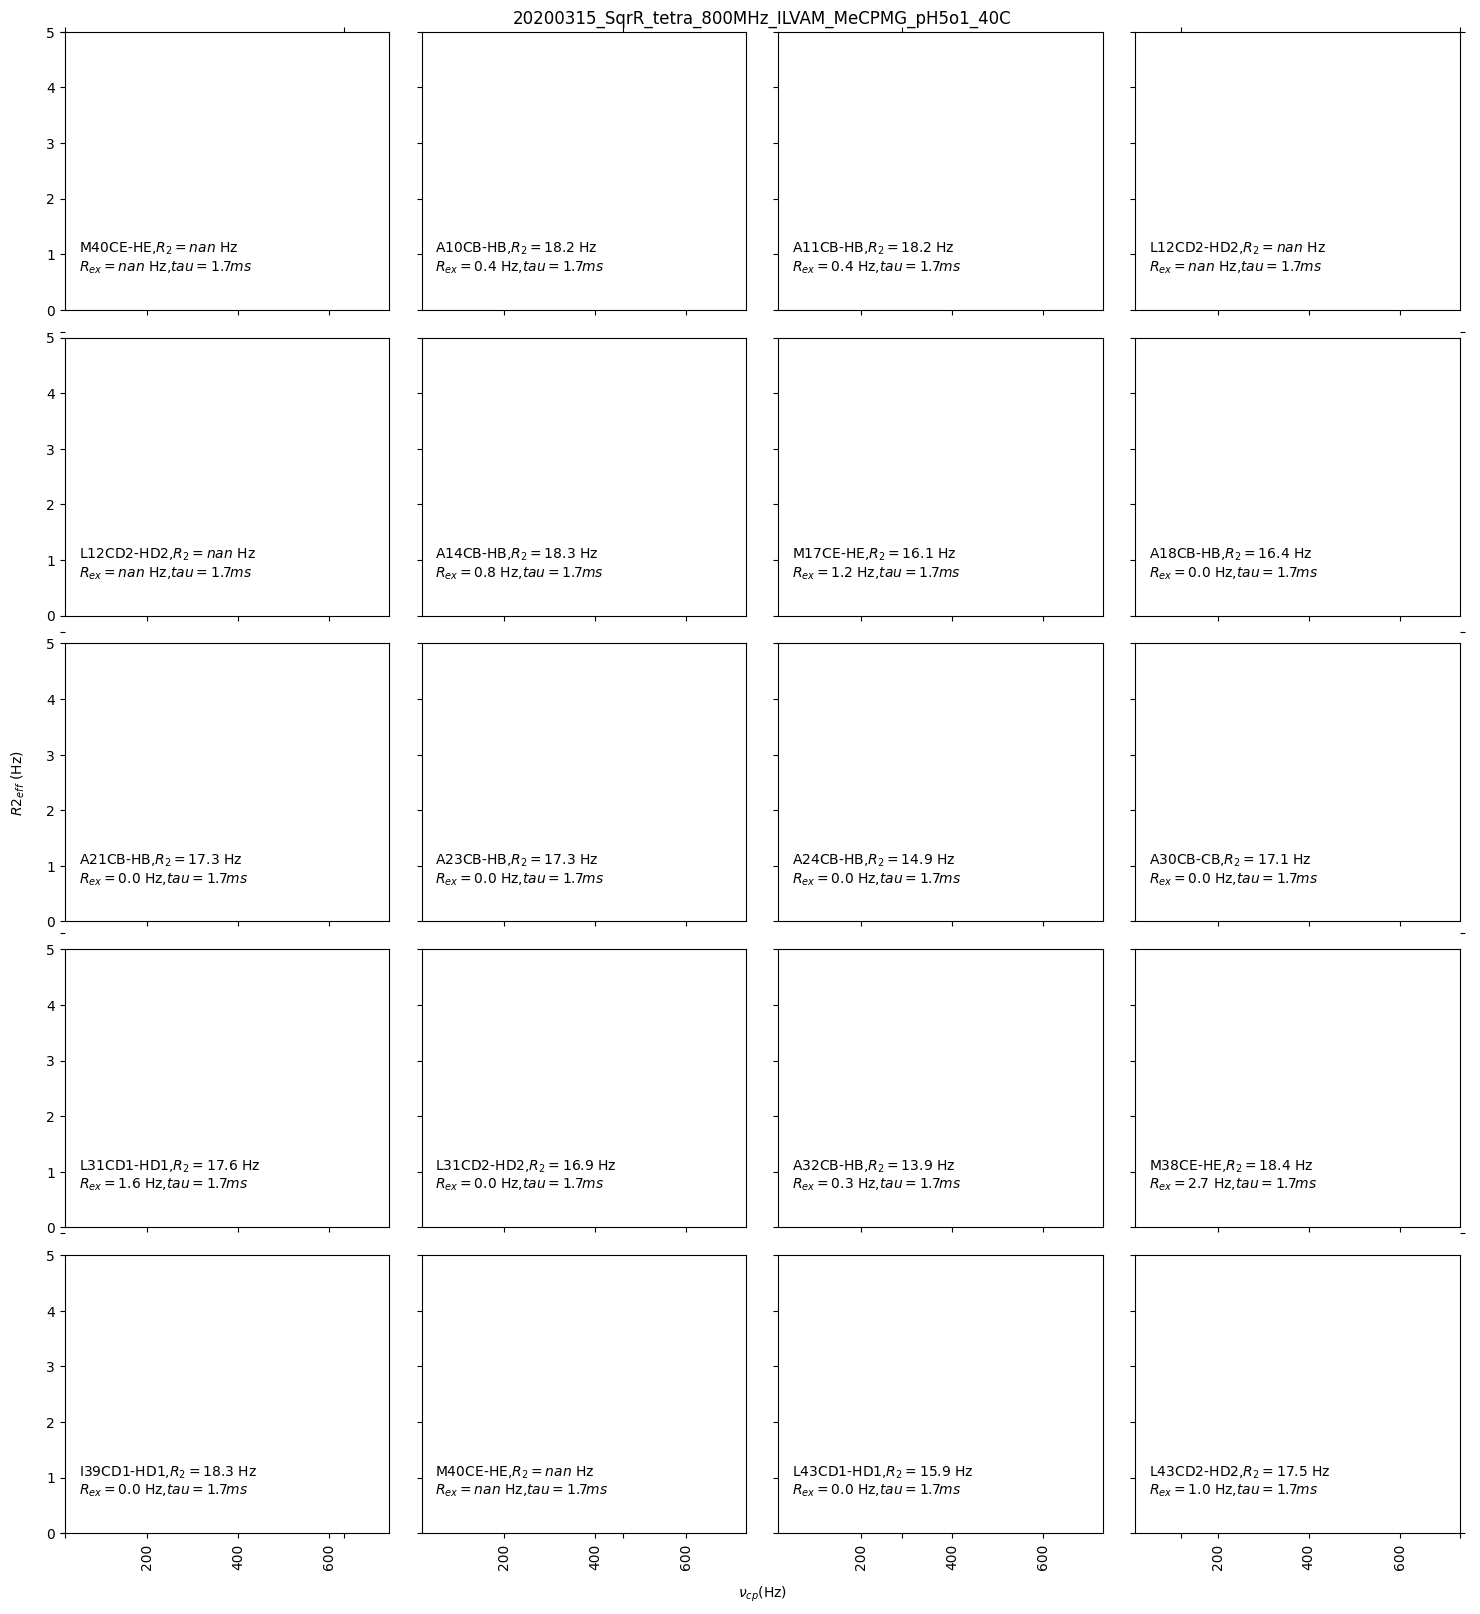

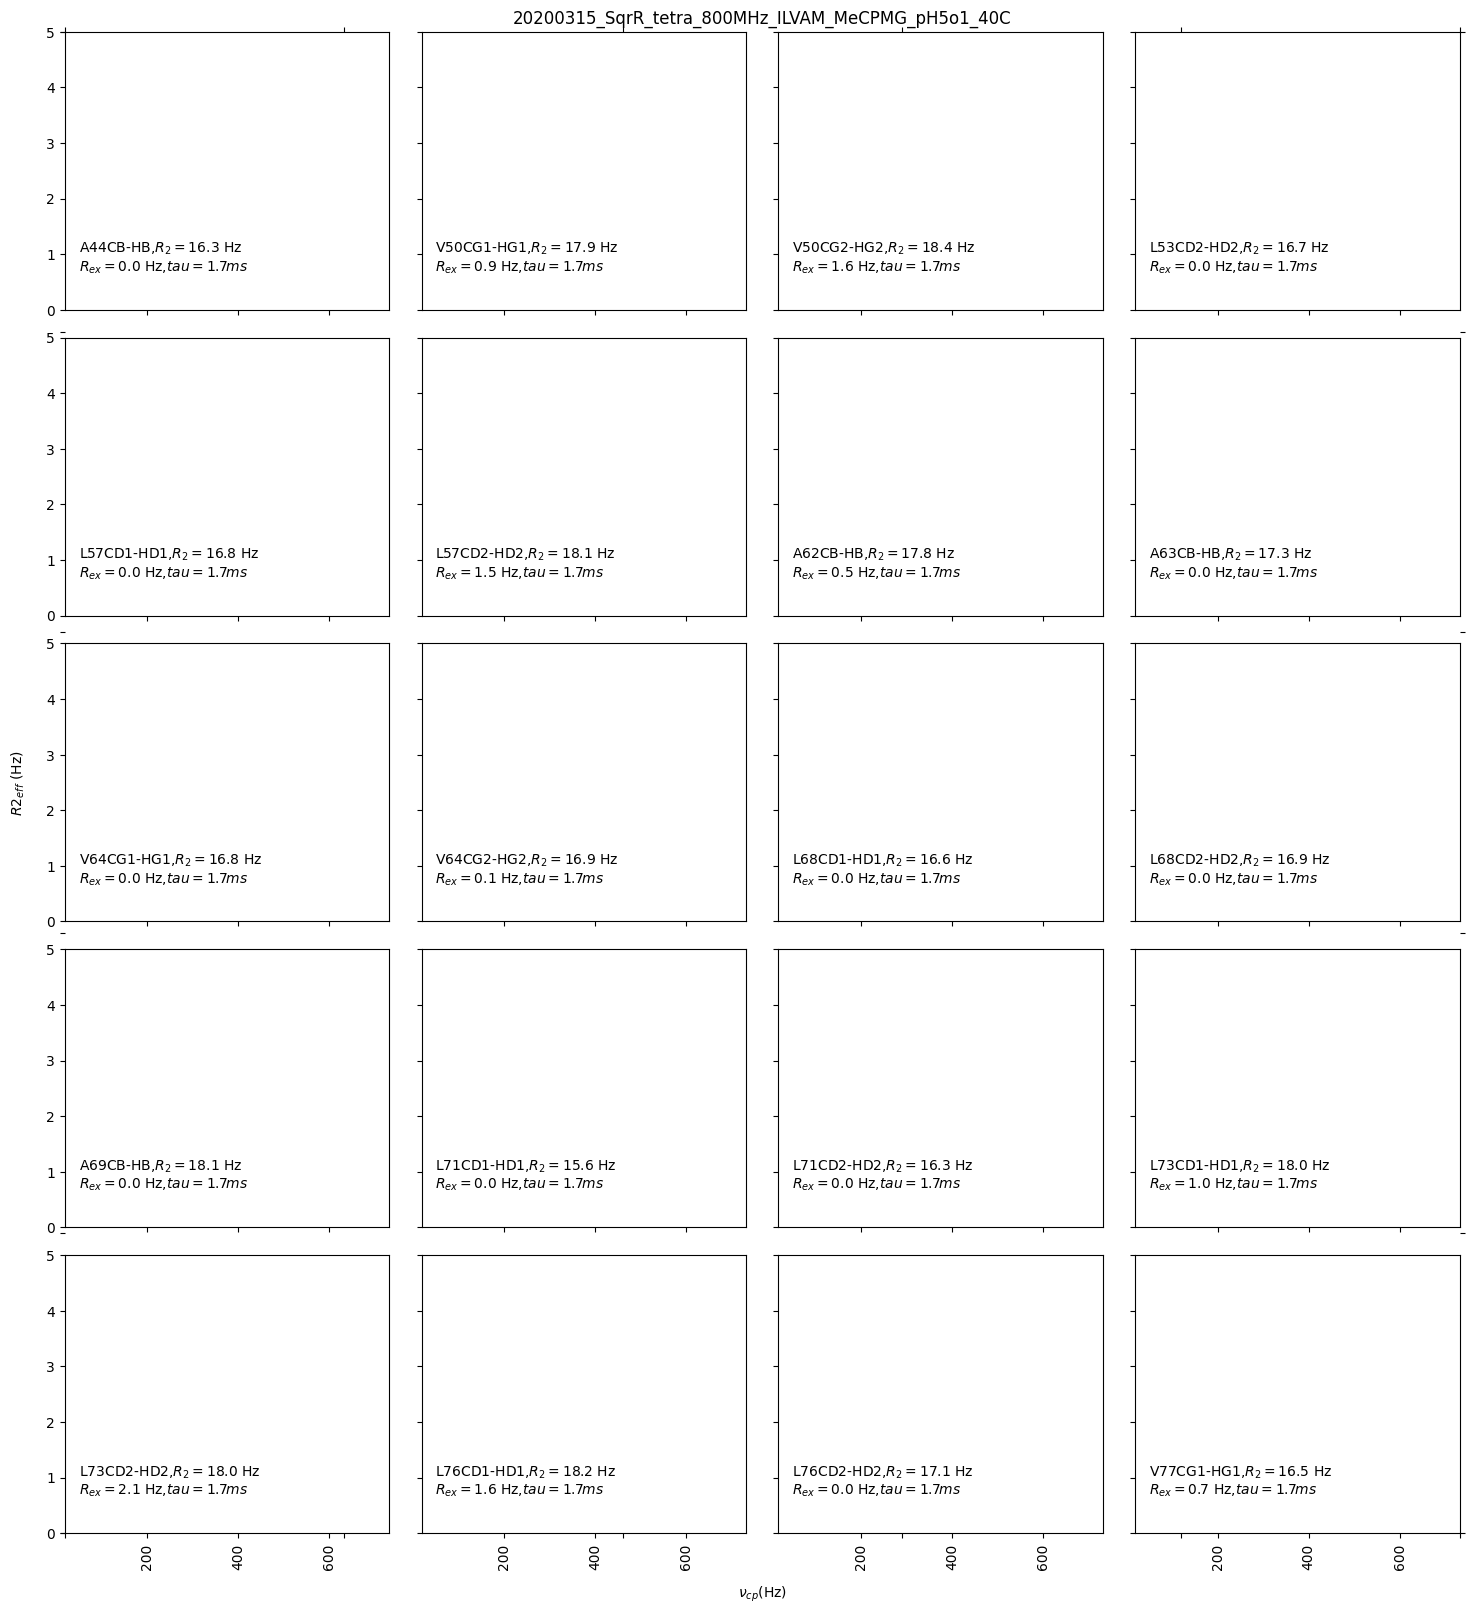

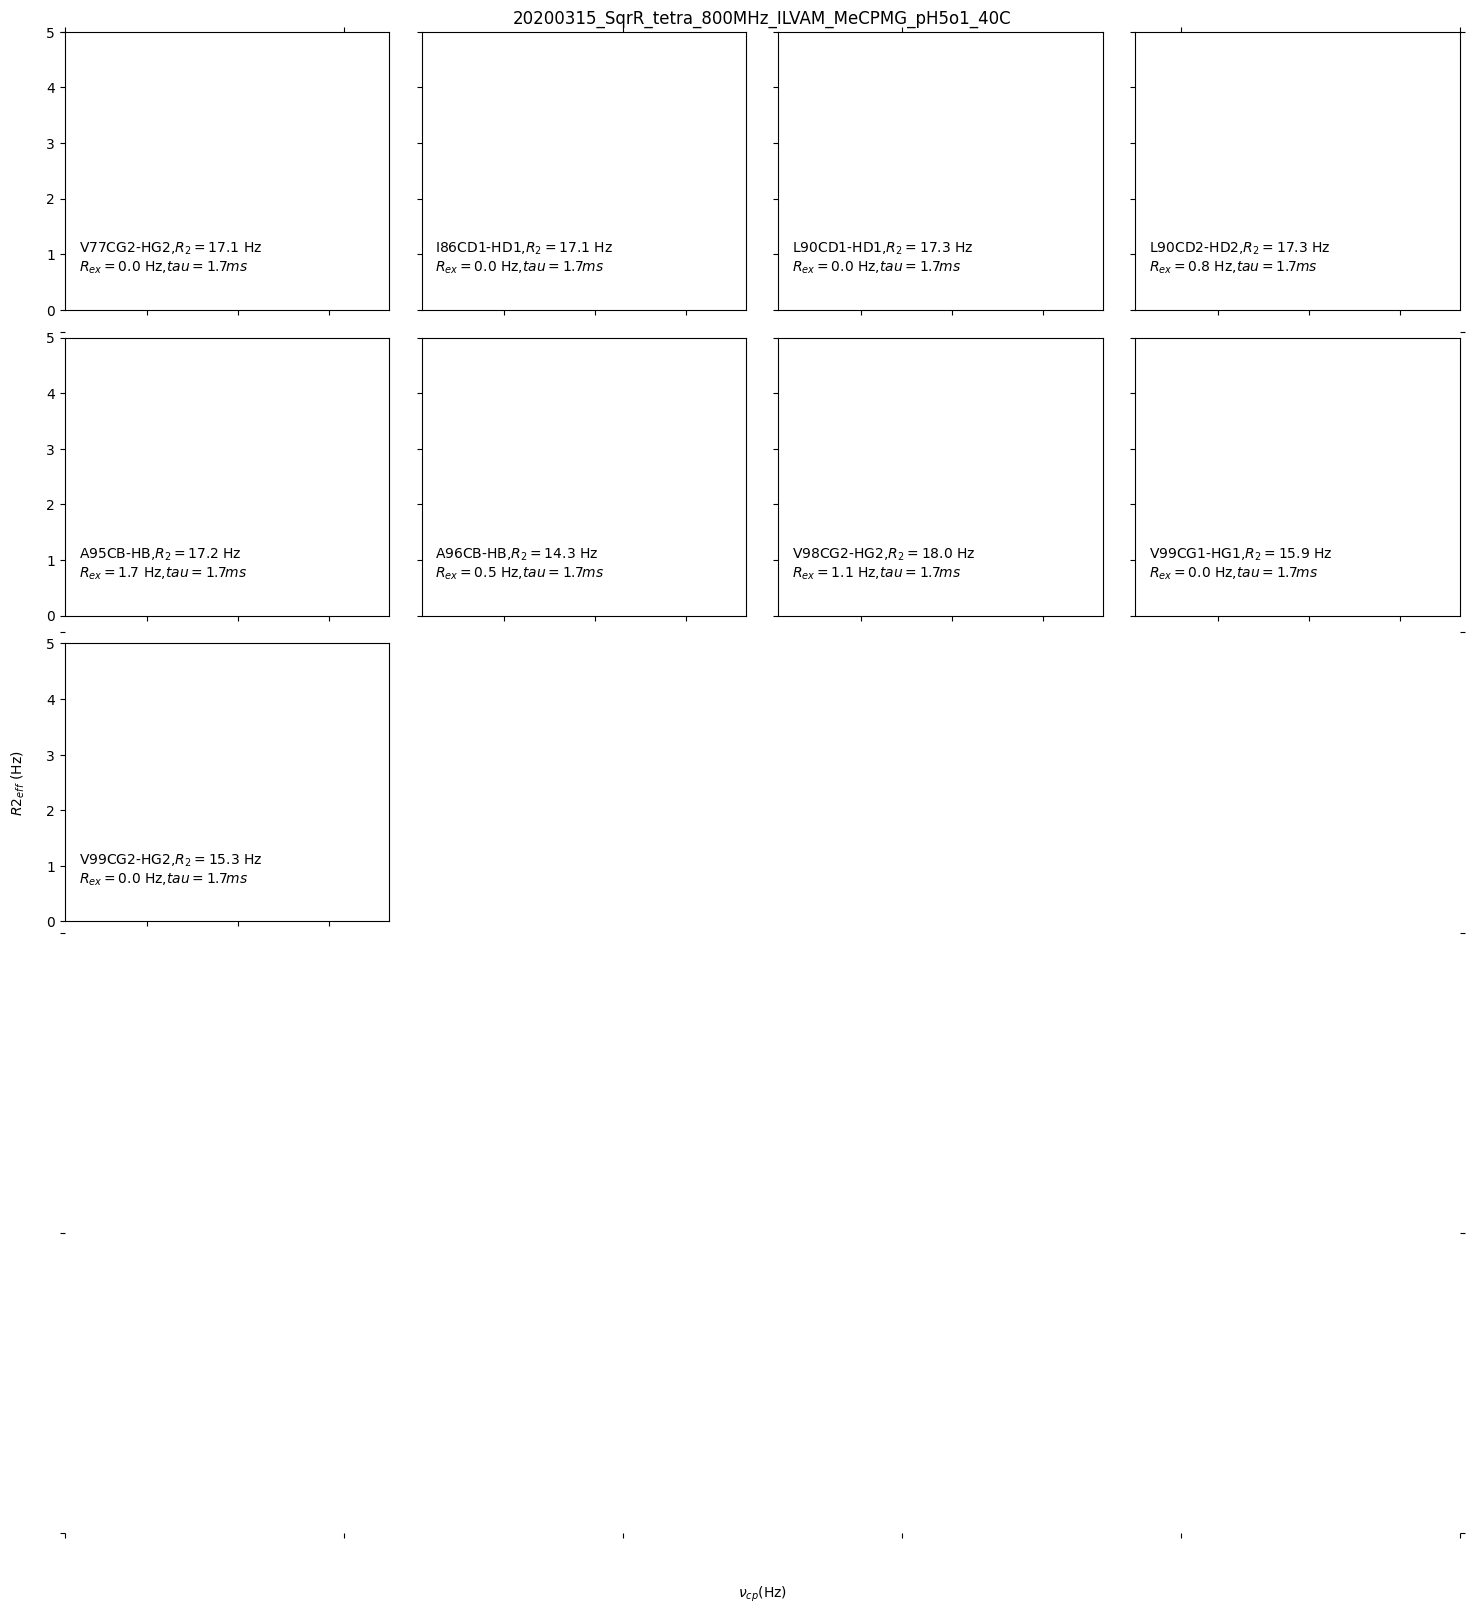

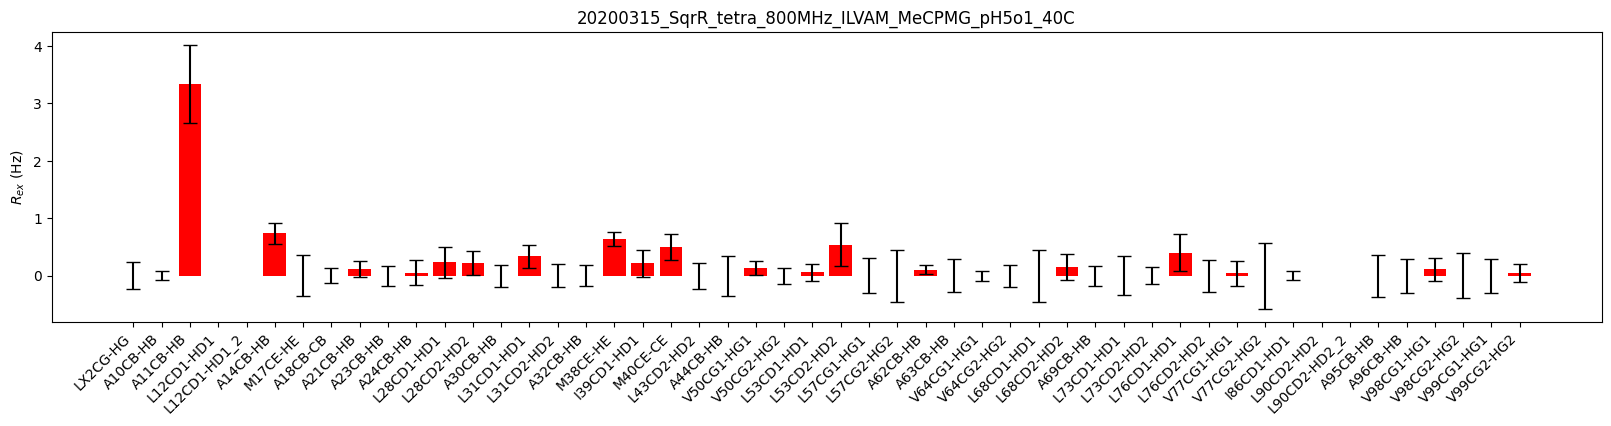

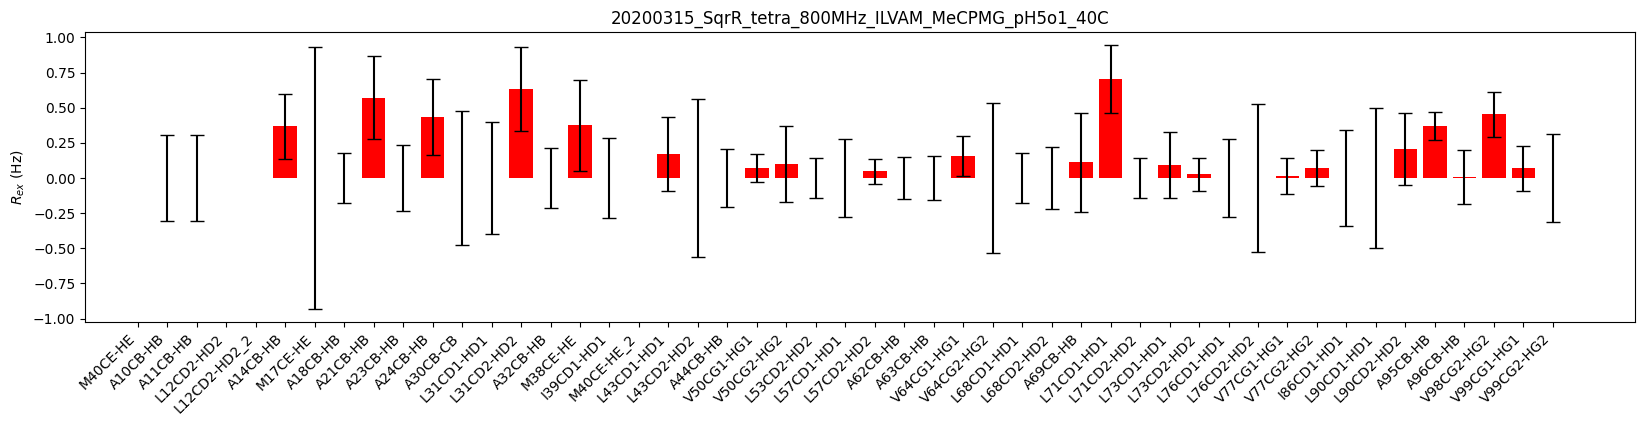

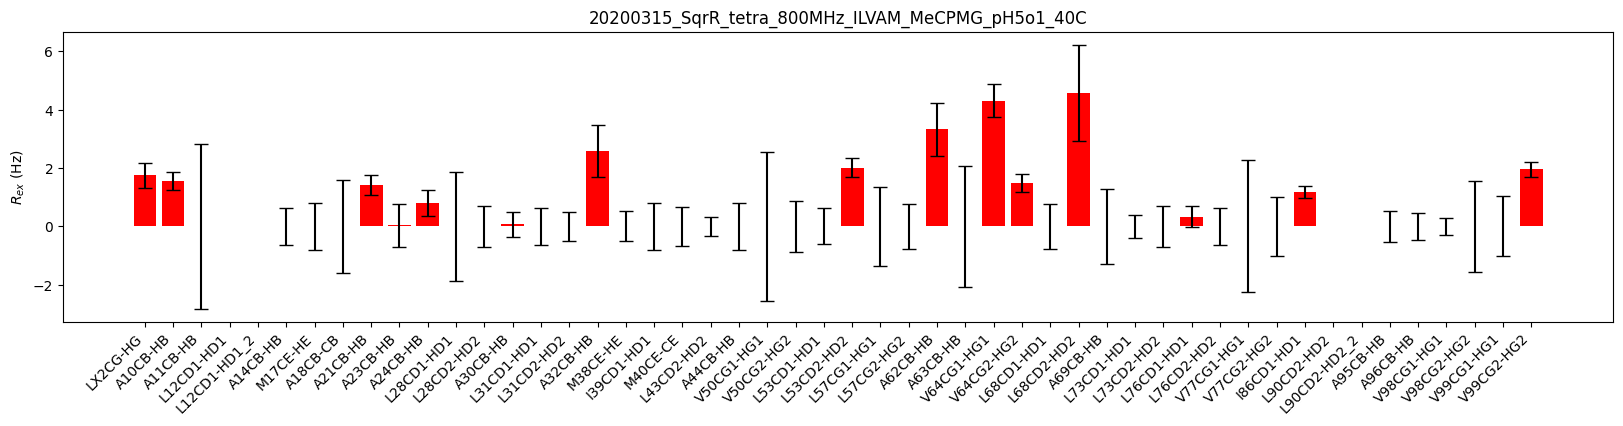

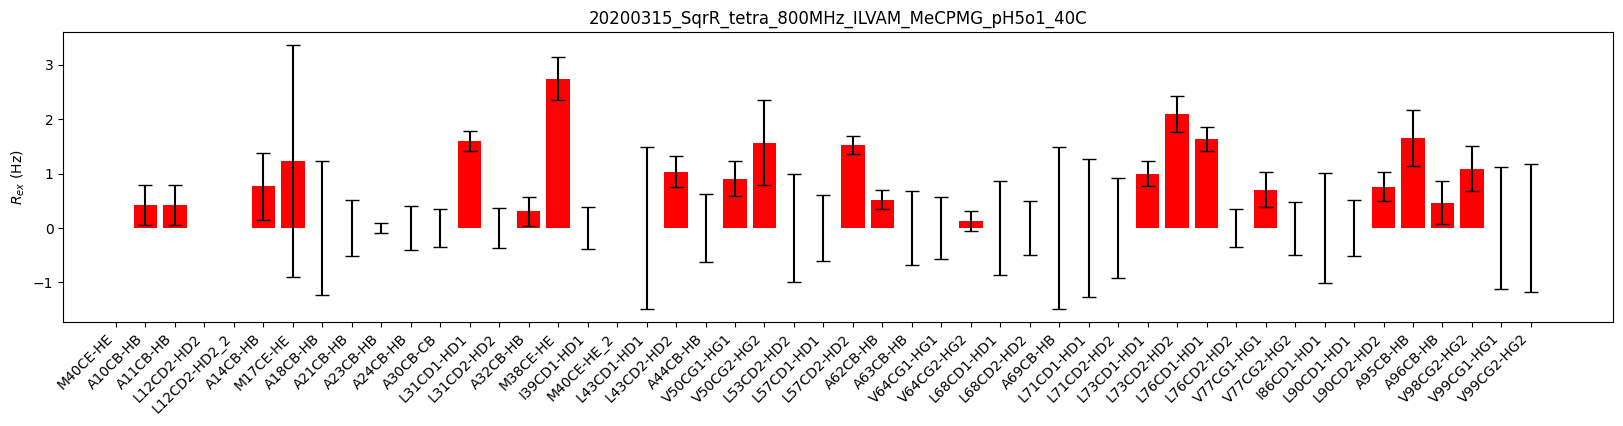

In [5]:
plotCurves(R2effs_600_red,all_fits_600_red)
plotCurves(R2effs_600_tetra,all_fits_600_tetra)
plotCurves(R2effs_800_red,all_fits_800_red)
plotCurves(R2effs_800_tetra,all_fits_800_tetra)

Rexbarplot(all_fits_600_red)
Rexbarplot(all_fits_600_tetra)
Rexbarplot(all_fits_800_red)
Rexbarplot(all_fits_800_tetra)

In [6]:
#plot individual residue
def selected_plots(R2effs, all_fits, fixed_tau, resnames = False, decay=True, barplot = False, compare_datasets = False ):
  if resnames == False:
    resnames = R2effs.index.values

  freqs = R2effs.columns.values
  combined_data = pd.concat([R2effs, all_fits], axis=1)

  if compare_datasets:
    R2effs_compare = compare_datasets[0]
    all_fits_compare = compare_datasets[1]
    freqs_compare = R2effs_compare.columns.values
    combined_data_compare = pd.concat([R2effs_compare, all_fits_compare], axis=1)

  for resname in resnames:
    R2efflist = combined_data[freqs].loc[resname].values
    R2_val = combined_data['R2'].loc[resname]
    R2_err_val = combined_data['R2_err'].loc[resname]
    Rex_val = combined_data['Rex'].loc[resname]
    Rex_err_val = combined_data['Rex_err'].loc[resname]
    Tau_ms = fixed_tau * 1000
    exp1 = r'$R_{2} = %.1f$' % R2_val + ' Hz'
    exp2 = r'$R_{ex} = %.1f$' % Rex_val + ' Hz'
    exp3 = r'$tau = %.1f ms$' % Tau_ms

    if compare_datasets:
      R2efflist_compare = combined_data_compare[freqs].loc[resname].values
      R2_val_compare = combined_data_compare['R2'].loc[resname]
      R2_err_val_compare = combined_data_compare['R2_err'].loc[resname]
      Rex_val_compare = combined_data_compare['Rex'].loc[resname]
      Rex_err_val = combined_data_compare['Rex_err'].loc[resname]
    if decay:
        y = R2efflist
        x = freqs
        if compare_datasets:
          y_compare = R2efflist_compare
          x_compare = freqs_compare

        plt.figure()
        plt.plot(x,y,'b.', label=resname)
        plt.plot(np.arange(0,700,1), fitFunc(np.arange(0,700,1),R2_val, Rex_val),'orange')
        if compare_datasets:
          plt.plot(x_compare,y_compare,'b.', label=resname)
          plt.plot(np.arange(0,700,1), fitFunc(np.arange(0,700,1),R2_val_compare, Rex_val_compare),'orange')
        plt.ylabel('$R2_{eff}$' + ' (Hz)')
        plt.xlabel(r'$\nu_{CPMG}$' + '(Hz)', labelpad=20)
        plt.annotate(exp1 + '\n' + exp2 + ',' + '\n' + exp3, xy=(10, 50), xycoords='axes points', horizontalalignment='left', verticalalignment='top')
        plt.legend()
        plt.show()
  if barplot:
      R2_val = combined_data['R2'].loc[resnames]
      R2_err_val = combined_data['R2_err'].loc[resnames]
      Rex_val = combined_data['Rex'].loc[resnames]
      Rex_err_val = combined_data['Rex_err'].loc[resnames]
      plt.figure()
      plt.bar(resnames, Rex_val, yerr=Rex_err_val,error_kw=dict(ecolor='black', capsize=5, elinewidth=1.5), color='red')
      plt.xticks(resnames, ha='right', rotation=45)
      plt.ylabel('$R_{ex}$' + ' ($s^{-1}$)')


In [7]:
#For coloring in pymol
def pymol_input(all_fits):
  for i in all_fits['Rex'].index:
    if 'L' in i:
      print(i[1:3],i[0],i[3:6],all_fits['Rex'][i])
    elif 'V' in i:
      print(i[1:3],i[0],i[3:6],all_fits['Rex'][i])
    elif 'I' in i:
      print(i[1:3],i[0],i[3:6],all_fits['Rex'][i])
    else:
      print(i[1:3],i[0], i[3:5],all_fits['Rex'][i])

In [8]:
pymol_input(all_fits_600_red)
#pymol_input(all_fits_600_tetra)
#pymol_input(all_fits_800_red)
#pymol_input(all_fits_800_tetra)

X2 L CG- 2.9064896488759182e-08
10 A CB 1.9033759776174733e-12
11 A CB 3.3358635686482163
12 L CD1 Assignment
L12CD1-HD1    NaN
L12CD1-HD1    NaN
Name: Rex, dtype: object
12 L CD1 Assignment
L12CD1-HD1    NaN
L12CD1-HD1    NaN
Name: Rex, dtype: object
14 A CB 0.7388305825994238
17 M CE 2.5763412134855774e-13
18 A CB 3.631220263125298e-13
21 A CB 0.11720857827169567
23 A CB 3.973220563240629e-08
24 A CB 0.05420008099045916
28 L CD1 0.232851154981529
28 L CD2 0.21917838274517792
30 A CB 1.8811134101883325e-14
31 L CD1 0.3411034276436162
31 L CD2 3.395697504374195e-08
32 A CB 2.896304070981089e-12
38 M CE 0.6339537057039772
39 I CD1 0.21427469478581576
40 M CE 0.5021628498927053
43 L CD2 1.095736649150454e-12
44 A CB 1.1575215449941792e-10
50 V CG1 0.13777175839201924
50 V CG2 4.3087040374904465e-15
53 L CD1 0.05840376421456611
53 L CD2 0.5396286706788961
57 L CG1 7.411738109476616e-12
57 L CG2 1.5863983061406957e-11
62 A CB 0.10904880153715707
63 A CB 8.373000311659941e-10
64 V CG1 1.711

In [9]:
def compare_CSP(all_fits):
    df_Rex = all_fits[['Rex','Rex_err']].reset_index()
    return df_Rex
Rex_Red_800MHz = compare_CSP(all_fits_800_red)
#print(Rex_Red_800MHz)
Rex_Tetra_800MHz = compare_CSP(all_fits_800_tetra)
print(Rex_Tetra_800MHz)

    Assignment       Rex   Rex_err
0     M40CE-HE       NaN       NaN
1     A10CB-HB  0.425672  0.367214
2     A11CB-HB  0.425672  0.367214
3   L12CD2-HD2       NaN       NaN
4   L12CD2-HD2       NaN       NaN
5     A14CB-HB  0.765814   0.61302
6     M17CE-HE  1.229244  2.130315
7     A18CB-HB       0.0  1.222867
8     A21CB-HB       0.0  0.518735
9     A23CB-HB       0.0   0.09609
10    A24CB-HB       0.0  0.399663
11    A30CB-CB       0.0  0.357494
12  L31CD1-HD1   1.60107  0.186802
13  L31CD2-HD2       0.0  0.372111
14    A32CB-HB  0.312094  0.266019
15    M38CE-HE  2.745273  0.396798
16  I39CD1-HD1  0.000002  0.392632
17    M40CE-HE       NaN       NaN
18  L43CD1-HD1       0.0  1.485813
19  L43CD2-HD2  1.038459  0.287104
20    A44CB-HB       0.0  0.632237
21  V50CG1-HG1  0.908108  0.321914
22  V50CG2-HG2  1.569617  0.783916
23  L53CD2-HD2       0.0  0.985718
24  L57CD1-HD1       0.0  0.606086
25  L57CD2-HD2  1.527343  0.158347
26    A62CB-HB  0.519402  0.172245
27    A63CB-HB      

In [10]:
pd.set_option('display.max_columns', None) # Muestra todas las columnas
pd.set_option('display.width', 300)       # Evita el ajuste de línea por ancho, mostrando el DataFrame en una sola línea por fila si es posible
pd.set_option('display.max_rows', None)    # Muestra todas las filas
print(pd.concat([R2effs_600_red, all_fits_600_red], axis=1))

                   50        100        150        200        250        300        350        400        450        500        600        700        850       1000         R2    R2_err       Rex   Rex_err
Assignment                                                                                                                                                                                                   
LX2CG-HG    30.497682  30.428636  30.285839  30.738172  30.463135  30.133368  30.193719  30.241053  30.633675  30.628328  30.625655  30.663105  30.740857  30.505662  30.484206  0.083488       0.0  0.234719
A10CB-HB    21.879861  21.976041  21.971453  21.875290  21.866151  21.976041  21.889005  21.953107  21.971453  22.003589  22.091026  22.040367  22.031168  22.017375   21.96728   0.02827       0.0  0.079479
A11CB-HB    28.617269  27.447280  28.009628  28.088742  27.711258  26.942676  26.799279  26.686649  26.470327  25.992160  25.111611  25.323537  26.634262  26.500053  26.007022 

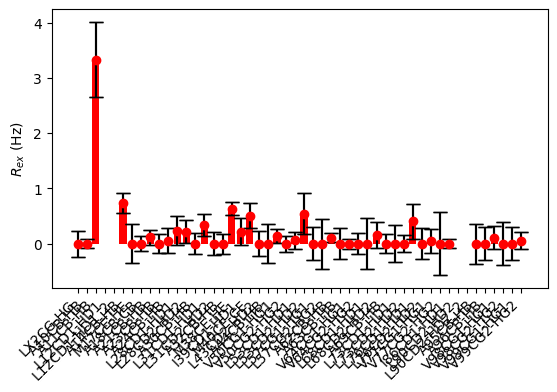

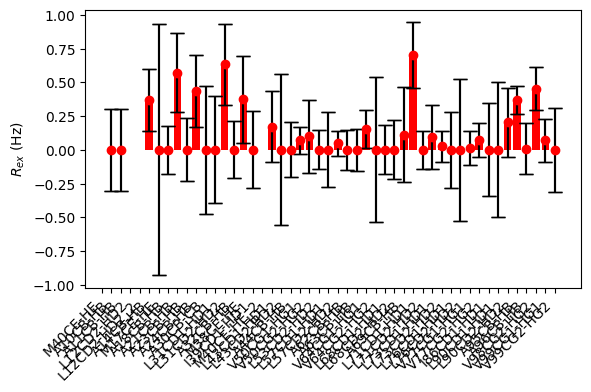

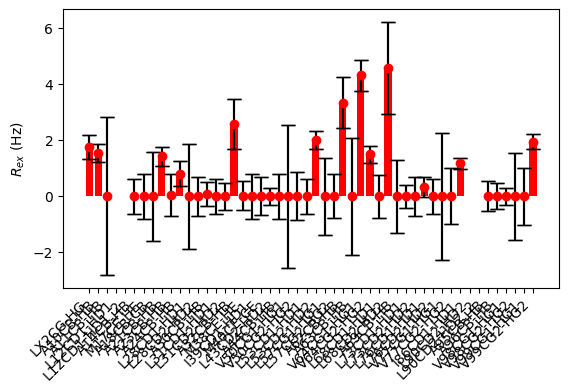

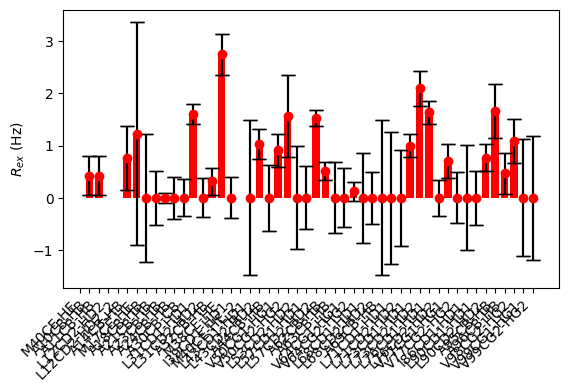

In [11]:
def Rex_scatterplot(all_fits):
    # Generate unique labels for assignments, handling duplicates
    unique_assignments_list = []
    counts = {}
    for ass in all_fits.index:
        counts[ass] = counts.get(ass, 0) + 1
        if counts[ass] > 1:
            unique_assignments_list.append(f'{ass}_{counts[ass]}')
        else:
            unique_assignments_list.append(ass)

    Rexvalues = all_fits['Rex'].values
    Rexerrors = all_fits['Rex_err'].values

    plt.errorbar(np.arange(len(unique_assignments_list)),
                  Rexvalues,
                  color='red',
                  yerr=Rexerrors,
                  capsize=5, # Added capsize for error bars
                  ecolor = 'black',
                  fmt='o') # Add format string for points to distinguish from lines

    plt.subplots_adjust(bottom=0.3)
    # The x-tick positions should be the same as the x-values provided to errorbar
    xticks_pos = np.arange(len(unique_assignments_list))
    plt.bar(unique_assignments_list, Rexvalues, yerr=Rexerrors,error_kw=dict(ecolor='black', capsize=5, elinewidth=1.5), color='red')
    plt.xticks(unique_assignments_list, ha='right', rotation=45)
    plt.ylabel('$R_{ex}$' + ' (Hz)')
    plt.show()

Rex_scatterplot(all_fits_600_red)
Rex_scatterplot(all_fits_600_tetra)
Rex_scatterplot(all_fits_800_red)
Rex_scatterplot(all_fits_800_tetra)

In [12]:
def multi_Rex_scatterplot(all_fits_dict, selected_resnames=None):
    all_rex_data = []

    # 3. Iterate through each key-value pair
    for dataset_name, all_fits_df in all_fits_dict.items():
        # 4. Extract 'Rex' and 'Rex_err' columns and reset index
        current_df = all_fits_df[['Rex', 'Rex_err']].reset_index()

        # 5. Add a new column 'Source' to each DataFrame
        current_df['Source'] = dataset_name

        # 6. Append this processed data to the all_rex_data list
        all_rex_data.append(current_df)

    # 7. Concatenate all items into a single pandas DataFrame
    consolidated_df = pd.concat(all_rex_data, ignore_index=True)

    # 8. Filter if selected_resnames is provided
    if selected_resnames is not None:
        # Ensure 'Assignment' column is present after reset_index
        consolidated_df = consolidated_df[consolidated_df['Assignment'].isin(selected_resnames)]

    # Drop rows where 'Rex' is NaN (failed fits) to avoid plotting issues
    consolidated_df.dropna(subset=['Rex'], inplace=True)

    # 9. From the (potentially filtered) consolidated_df, identify all unique residue assignments.
    unique_assignments_raw = consolidated_df['Assignment'].unique()

    # Parse each unique assignment into (residue number, residue name, atom name)
    parsed_assignments = []
    for ass_str in unique_assignments_raw:
        try:
            # format_label returns (resi, resn, atom_name)
            resi, resn, atom_name = format_label(ass_str)
            # Store as a tuple (int(resi), resn, atom_name, original_assignment_string) for sorting
            parsed_assignments.append((int(resi), resn, atom_name, ass_str))
        except ValueError as e:
            print(f"Warning: Could not parse assignment '{ass_str}': {e}. Skipping this assignment.")
            continue

    # 10. Sort these unique assignments numerically by residue number, then alphabetically by residue name,
    # and finally alphabetically by atom name.
    sorted_parsed_assignments = sorted(parsed_assignments, key=lambda x: (x[0], x[1], x[2]))

    # Get the ordered list of original assignment strings for plotting x-axis labels
    ordered_assignment_labels = [item[3] for item in sorted_parsed_assignments]

    # --- Plotting Logic ---
    fig, ax = plt.subplots(figsize=(18, 7))

    # Define colors and markers for different datasets
    colors = plt.colormaps.get_cmap('tab10') # Corrected: Removed the second argument
    markers = ['o', 's', '^', 'D', 'p', '*', 'h', '+', 'x', '|']

    # Get unique sources for iteration
    unique_sources = consolidated_df['Source'].unique()

    for i, source in enumerate(unique_sources):
        source_df = consolidated_df[consolidated_df['Source'] == source].copy()

        # Filter source_df to include only assignments present in ordered_assignment_labels
        source_df_filtered = source_df[source_df['Assignment'].isin(ordered_assignment_labels)]

        # Remove rows with NaN Rex after filtering if any (for assignments not present in this source)
        source_df_filtered.dropna(subset=['Rex'], inplace=True)

        if source_df_filtered.empty:
            continue

        # Create a mapping for x-coordinates based on the global ordered_assignment_labels
        assignment_to_x_coord = {ass: idx for idx, ass in enumerate(ordered_assignment_labels)}
        source_df_filtered['x_coord'] = source_df_filtered['Assignment'].map(assignment_to_x_coord)

        # Sort the DataFrame by this new x_coord to ensure correct plotting order
        source_df_filtered = source_df_filtered.sort_values(by='x_coord')

        ax.errorbar(source_df_filtered['x_coord'],
                    source_df_filtered['Rex'],
                    yerr=source_df_filtered['Rex_err'],
                    fmt=markers[i % len(markers)], # Use different marker for each source
                    color=colors(i),              # Use different color for each source
                    capsize=5,
                    label=source)

    # Set x-axis ticks and labels
    ax.set_xticks(range(len(ordered_assignment_labels)))
    ax.set_xticklabels(ordered_assignment_labels, rotation=60, ha='right')

    ax.set_xlabel('Residue Assignment')
    ax.set_ylabel('$R_{ex}$' + ' (Hz)')
    ax.set_title('Rex Values for Different Datasets')
    ax.legend(title='Dataset')
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()

print("multi_Rex_scatterplot function (with plotting) defined.")

multi_Rex_scatterplot function (with plotting) defined.


Plotting Rex values for all available residues across datasets:


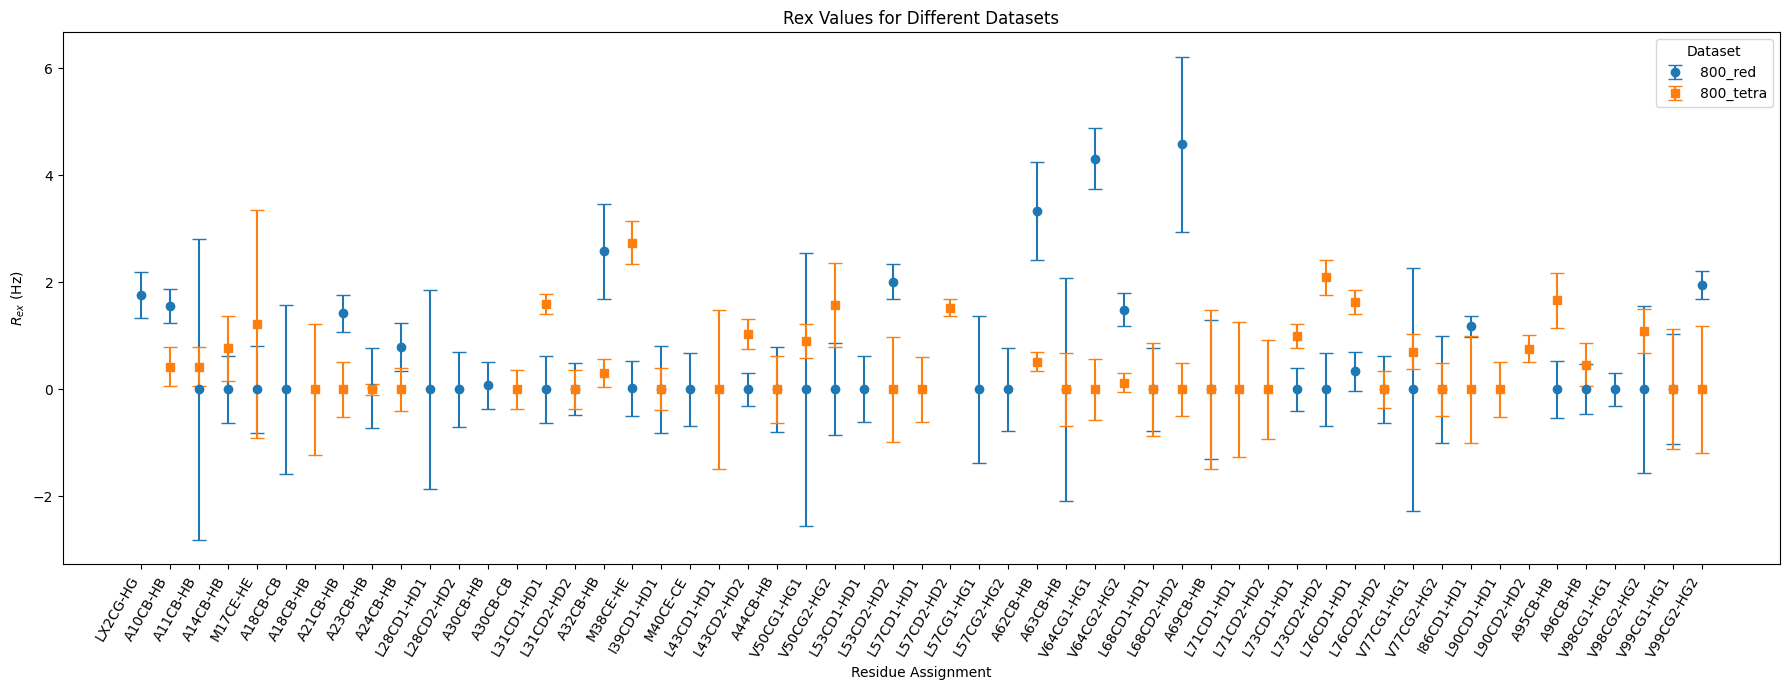


Plotting Rex values for selected residues across datasets:


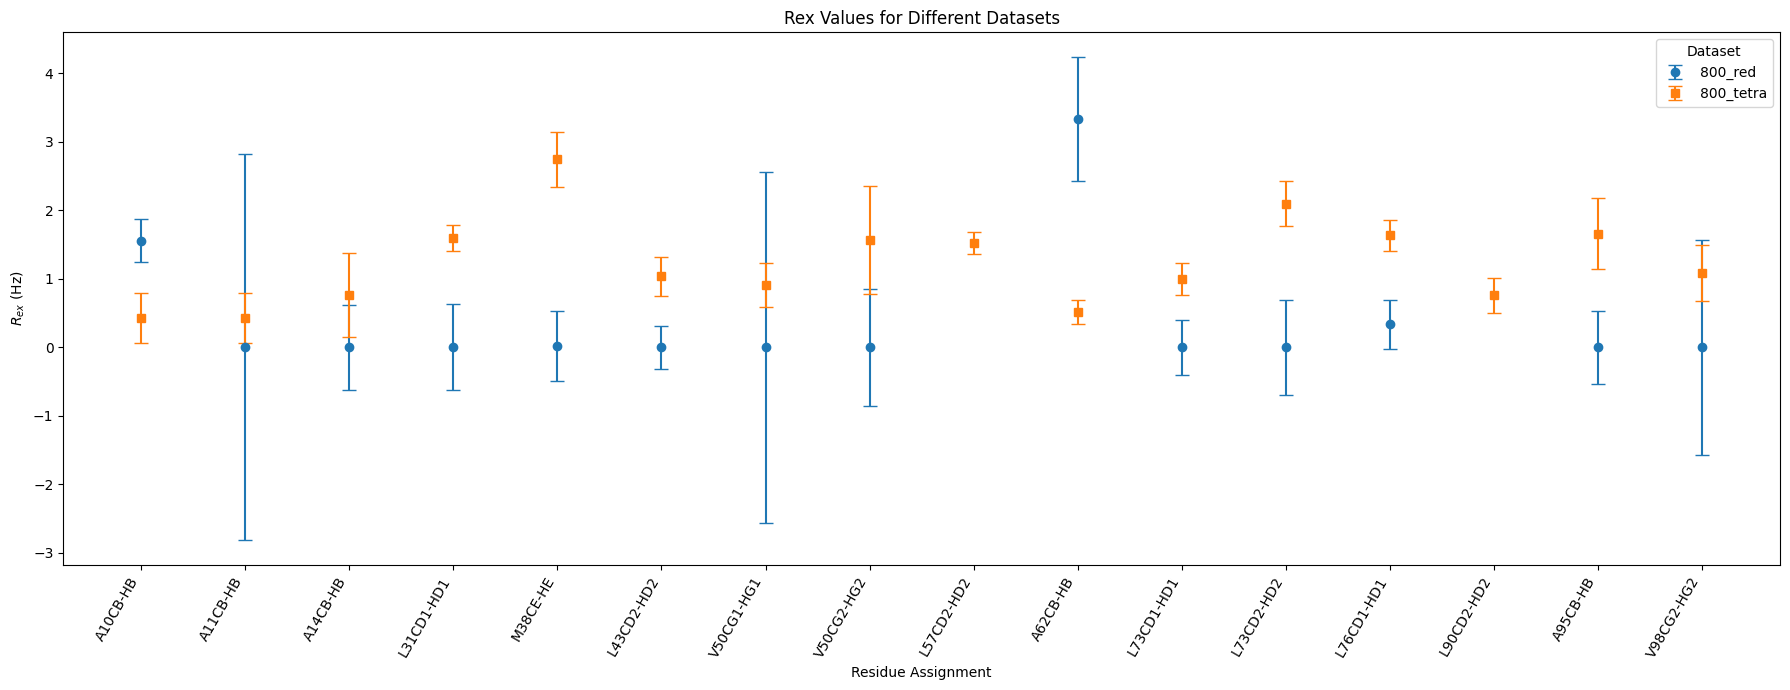

In [13]:
all_fits_dataframes = {
    '800_red': all_fits_800_red,
    '800_tetra': all_fits_800_tetra
}

# 1. Call multi_Rex_scatterplot to plot all available residues
print("Plotting Rex values for all available residues across datasets:")
multi_Rex_scatterplot(all_fits_dataframes, selected_resnames=None)

# 2. Call multi_Rex_scatterplot again to plot a specific subset of residues
selected_resnames_list = [
    'M4CE-HE',
    'A10CB-HB',
    'A11CB-HB',
    'A14CB-HB',
    'L31CD1-HD1',
    'M38CE-HE',
    'L43CD2-HD2',
    'V50CG1-HG1',
    'V50CG2-HG2',
    'L57CD2-HD2',
    'A62CB-HB',
    'L73CD1-HD1',
    'L73CD2-HD2',
    'L76CD1-HD1',
    'L90CD2-HD2',
    'A95CB-HB',
    'V98CG2-HG2'
]
print("\nPlotting Rex values for selected residues across datasets:")
multi_Rex_scatterplot(all_fits_dataframes, selected_resnames=selected_resnames_list)

In [14]:
def assignment_2_xticks(list_of_assignments):
  xticks = []
  for orig_ass in list_of_assignments:
    # Use the existing format_label function for robust parsing
    try:
        # format_label returns (resi_str, resn_3letter, atom_name_from_label)
        resi, resn_3letter, atom_name_from_label = format_label(orig_ass)
        resn_1letter = one_letter[resn_3letter] # Get 1-letter code from 3-letter

        atom_type_latex = ""
        atom_suffix = ""

        # Map the atom_name_from_label to the desired LaTeX format and suffix
        if resn_1letter == 'L':
            if 'CD1' in atom_name_from_label:
                atom_type_latex = r'C$\delta$'
                atom_suffix = '1'
            elif 'CD2' in atom_name_from_label:
                atom_type_latex = r'C$\delta$'
                atom_suffix = '2'
            elif 'CG1' in atom_name_from_label:
                 atom_type_latex = r'C$\gamma$'
                 atom_suffix = '1'
            elif 'CG2' in atom_name_from_label:
                 atom_type_latex = r'C$\gamma$'
                 atom_suffix = '2'
            else: # Fallback if specific atom not matched (e.g., just 'CG')
                atom_type_latex = atom_name_from_label # No leading space here
        elif resn_1letter == 'V':
            if 'CG1' in atom_name_from_label:
                atom_type_latex = r'C$\gamma$'
                atom_suffix = '1'
            elif 'CG2' in atom_name_from_label:
                atom_type_latex = r'C$\gamma$'
                atom_suffix = '2'
            else:
                atom_type_latex = atom_name_from_label
        elif resn_1letter == 'I':
            if 'CD1' in atom_name_from_label:
                atom_type_latex = r'C$\delta$'
                atom_suffix = '1'
            elif 'CG1' in atom_name_from_label:
                 atom_type_latex = r'C$\gamma$'
                 atom_suffix = '1'
            elif 'CG2' in atom_name_from_label:
                 atom_type_latex = r'C$\gamma$'
                 atom_suffix = '2'
            else:
                atom_type_latex = atom_name_from_label
        elif resn_1letter == 'A':
            # Assuming 'CB' is the primary atom for Alanine CPMG
            if 'CB' in atom_name_from_label:
                atom_type_latex = r'C$\beta$'
                atom_suffix = ''
            else:
                atom_type_latex = atom_name_from_label
        elif resn_1letter == 'M':
            # Assuming 'CE' is the primary atom for Methionine CPMG
            if 'CE' in atom_name_from_label:
                atom_type_latex = r'C$\epsilon$'
                atom_suffix = ''
            else:
                atom_type_latex = atom_name_from_label
        else: # Generic fallback for other residues not explicitly handled
            atom_type_latex = atom_name_from_label
            atom_suffix = ''

        # Construct the final tick label with exactly one space after the residue number
        tick = f"{resn_1letter}{resi} {atom_type_latex}{atom_suffix}"
        xticks.append(tick)
    except Exception as e: # Catch any parsing or mapping errors
        # If any error occurs, just use the original assignment as a fallback
        print(f"Warning: Failed to format label for '{orig_ass}'. Using original string. Error: {e}")
        xticks.append(orig_ass)
  return xticks

def multi_Rex_scatterplot(all_fits_dict, selected_resnames_dict=None, set_colors=False, save=False, labels = [], x_axis_labels=False):
    all_rex_data = []

    # 3. Iterate through each key-value pair
    for dataset_name, all_fits_df in all_fits_dict.items():
        # 4. Extract 'Rex' and 'Rex_err' columns and reset index
        current_df = all_fits_df[['Rex', 'Rex_err']].reset_index()

        # Add per-dataset filtering
        if selected_resnames_dict is not None and dataset_name in selected_resnames_dict:
            current_df = current_df[current_df['Assignment'].isin(selected_resnames_dict[dataset_name])]

        # 5. Add a new column 'Source' to each DataFrame
        current_df['Source'] = dataset_name

        # 6. Append this processed data to the all_rex_data list
        all_rex_data.append(current_df)

    # 7. Concatenate all items into a single pandas DataFrame
    consolidated_df = pd.concat(all_rex_data, ignore_index=True)

    # 4. Remove the previous global filtering step that checked `if selected_resnames is not None`
    # The per-dataset filtering has replaced this.

    # Drop rows where 'Rex' is NaN (failed fits) to avoid plotting issues
    consolidated_df.dropna(subset=['Rex'], inplace=True)

    # 9. From the (potentially filtered) consolidated_df, identify all unique residue assignments.
    unique_assignments_raw = consolidated_df['Assignment'].unique()

    # Parse each unique assignment into (residue number, residue name, atom name)
    parsed_assignments = []
    for ass_str in unique_assignments_raw:
        try:
            # format_label returns (resi, resn, atom_name)
            resi, resn, atom_name = format_label(ass_str)
            # Store as a tuple (int(resi), resn, atom_name, original_assignment_string) for sorting
            parsed_assignments.append((int(resi), resn, atom_name, ass_str))
        except ValueError as e:
            print(f"Warning: Could not parse assignment '{ass_str}': {e}. Skipping this assignment.")
            continue

    # 10. Sort these unique assignments numerically by residue number, then alphabetically by residue name,
    # and finally alphabetically by atom name.
    sorted_parsed_assignments = sorted(parsed_assignments, key=lambda x: (x[0], x[1], x[2]))

    # Get the ordered list of original assignment strings for plotting x-axis labels
    ordered_assignment_labels = [item[3] for item in sorted_parsed_assignments]

    # --- Plotting Logic ---
    fig, ax = plt.subplots(figsize=(18, 7))

    # Define colors and markers for different datasets
    colors = plt.colormaps.get_cmap('tab10') # Corrected: Removed the second argument
    if set_colors:
       colors = set_colors
    markers = ['o', 's', '^', 'D', 'p', '*', 'h', '+', 'x', '|']
    # Get unique sources for iteration
    unique_sources = consolidated_df['Source'].unique()

    for i, source in enumerate(unique_sources):
        source_df = consolidated_df[consolidated_df['Source'] == source].copy()

        # Filter source_df to include only assignments present in ordered_assignment_labels
        source_df_filtered = source_df[source_df['Assignment'].isin(ordered_assignment_labels)]

        # Remove rows with NaN Rex after filtering if any (for assignments not present in this source)
        source_df_filtered.dropna(subset=['Rex'], inplace=True)

        if source_df_filtered.empty:
            continue

        # Create a mapping for x-coordinates based on the global ordered_assignment_labels
        if x_axis_labels:
        # Create a mapping for x-coordinates based on the global ordered_assignment_labels
          x_axis_labels_list = list(x_axis_labels)
          ordered_assignment_labels = []
          for num, item in enumerate(x_axis_labels_list):
            if item == 'M':
              ordered_assignment_labels.append('M'+str(num+1)+'CE-HE')
            elif item == 'A':
              ordered_assignment_labels.append('A'+str(num+1)+'CB-HB')
            elif item == 'L':
              ordered_assignment_labels.append('L'+str(num+1)+'CD1-HD1')
              ordered_assignment_labels.append('L'+str(num+1)+'CD2-HD2')
            elif item == 'I':
              ordered_assignment_labels.append('I'+str(num+1)+'CD1-HD1')
              ordered_assignment_labels.append('I'+str(num+1)+'CD2-HD2')
            elif item == 'V':
              ordered_assignment_labels.append('V'+str(num+1)+'CG1-HG1')
              ordered_assignment_labels.append('V'+str(num+1)+'CG2-HG2')

        assignment_to_x_coord = {ass: idx for idx, ass in enumerate(ordered_assignment_labels)}

        source_df_filtered['x_coord'] = source_df_filtered['Assignment'].map(assignment_to_x_coord)

        # Sort the DataFrame by this new x_coord to ensure correct plotting order
        source_df_filtered = source_df_filtered.sort_values(by='x_coord')
        if set_colors:
          color = colors[i]
        else:
          color = colors(i)
        ax.errorbar(source_df_filtered['x_coord'],
                    source_df_filtered['Rex'],
                    yerr=source_df_filtered['Rex_err'],
                    fmt=markers[i % len(markers)], # Use different marker for each source
                    color=color,              # Use different color for each source
                    capsize=5,
                    label=labels[i])

    # Set x-axis ticks and labels
    ax.set_xticks(range(len(ordered_assignment_labels)))
    resids = []
    for e in ordered_assignment_labels:
       item = e.split('-')[0]
       resids.append(int(re.findall(r'\d+', item[:-1])[0]))

    # Set x-axis limits to provide symmetrical padding (half a tick interval on each side)
    ax.set_xlim(-0.5, len(ordered_assignment_labels) - 0.5)
    ax.set_xticklabels(assignment_2_xticks(ordered_assignment_labels), rotation=60, ha='center', fontsize=12)

    # Fix for UserWarning: set_ticklabels() should only be used with a fixed number of ticks
    y_ticks = ax.get_yticks()
    ax.set_yticks(y_ticks)
    ax.set_ylim(-0.95,8)
    ax.set_yticklabels(ax.get_yticks(), fontsize=12)

    ax.set_xlabel('Residue', fontsize=24)
    ax.set_ylabel('$R_{ex}$' + ' ($s^{-1}$)', fontsize= 24)
    #ax.set_title('Rex Values for Different Datasets')
    ax.legend(fontsize=20)
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    if save:
      plt.savefig('Rex_800MHz_barplot.svg', format='svg', bbox_inches='tight')
    plt.show()

print("multi_Rex_scatterplot function (with per-dataset filtering) redefined.")

multi_Rex_scatterplot function (with per-dataset filtering) redefined.



Plotting Rex values for selected residues from specific datasets:


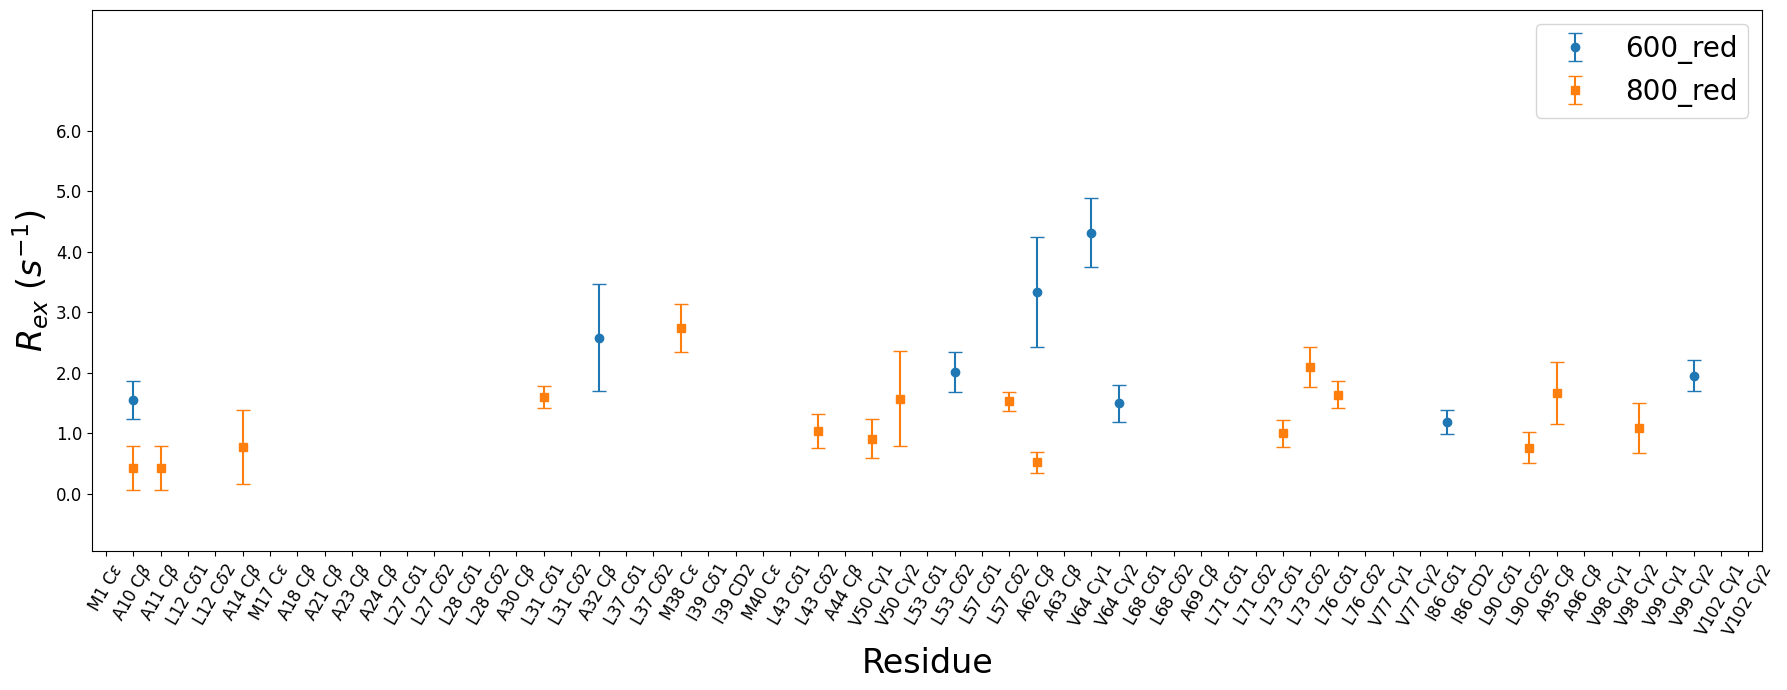

In [15]:
selected_resnames_dict = {
    '600_red': ['A11CB-HB', 'A14CB-HB','L31CD1-HD1','M38CE-HE'],
    '800_red': ['A10CB-HB', 'A32CB-HB','L53CD2-HD2','A62CB-HB','V64CG1-HG1','V64CG2-HG2','I86CD1-HD1','V99CG2-HG2'],
    '600_tetra': ['A14CB-HB', 'A21CB-HB', 'A24CB-HB', 'L31CD2-HD2', 'M38CE-HE','M40CE-HE','V64CG1-HG1','L71CD1-HD1', 'A95CB-HB','V98CG2-HG2'],
    '800_tetra': ['M40CE-HE','A10CB-HB','A11CB-HB','A14CB-HB',
                  'L31CD1-HD1','M38CE-HE','L43CD2-HD2','V50CG1-HG1',
                  'V50CG2-HG2','L57CD2-HD2', 'A62CB-HB','L73CD1-HD1',
                  'L73CD2-HD2', 'L76CD1-HD1', 'L90CD2-HD2', 'A95CB-HB', 'V98CG2-HG2']
}

print("\nPlotting Rex values for selected residues from specific datasets:")
multi_Rex_scatterplot(all_fits_dataframes, selected_resnames_dict=selected_resnames_dict, labels=['600_red','800_red','600_tetra','800_tetra'],
                      x_axis_labels= 'MGSDTDERSAALDAEEMATRARAASNLLKALAHEGRLMIMCYLASGEKSVTELETRLSTRQAAVSQQLARLRLEGLVQSRREGKTIYYSLSDPRAARVVQTVYEQFCSGD')


Plotting Rex values for selected residues from specific datasets:


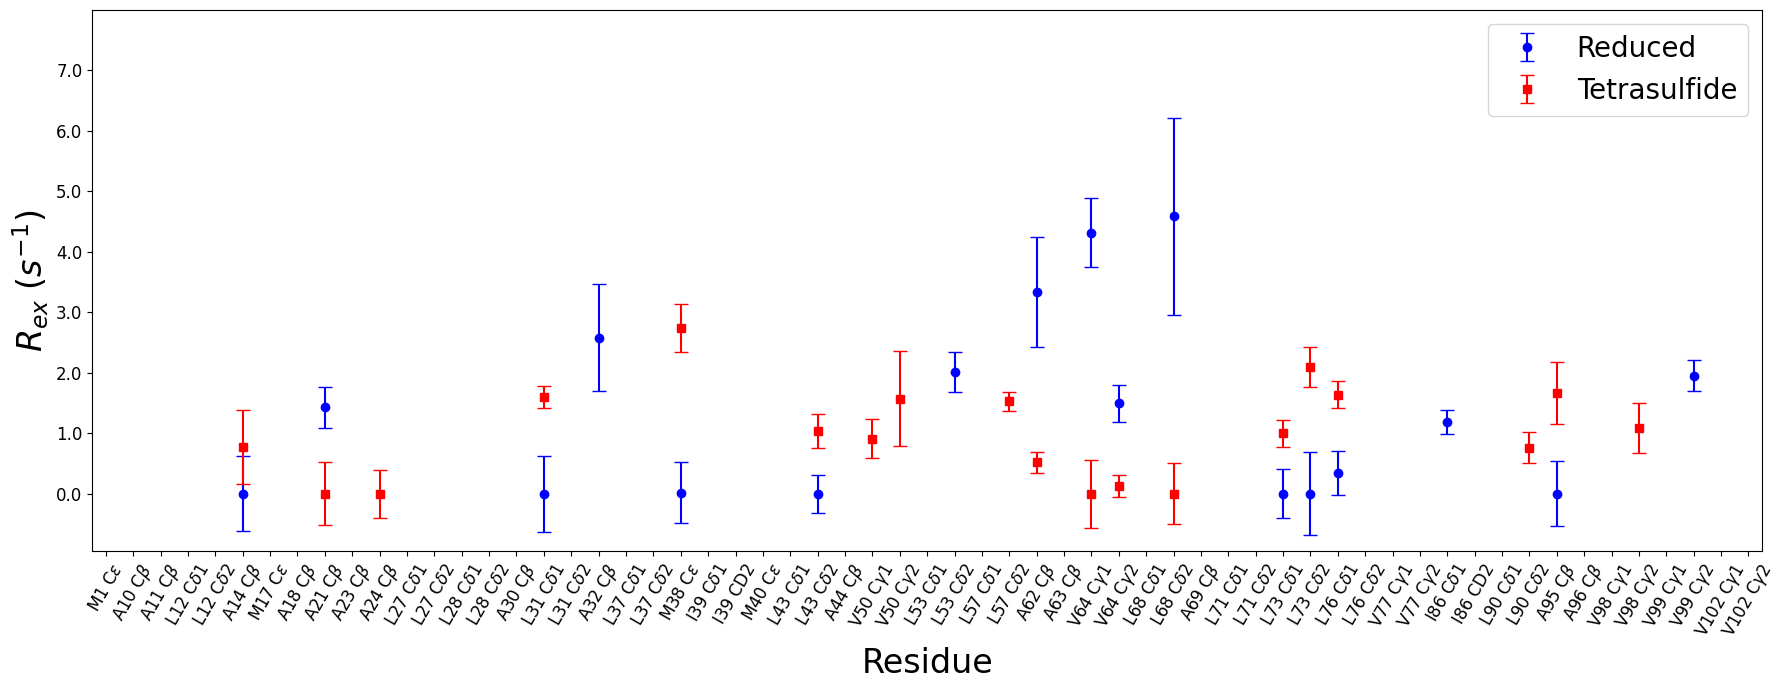

In [16]:
selected_resnames_dict_for_plot = {
    '800_red': ['A14CB-HB','A21CB-HB','A24CB-HB' 'A30CB-HB', 'L31CD1-HD1', 'A32CB-HB','M38CE-HE','L43CD2-HD2','L53CD2-HD2','A62CB-HB',
                'V64CG1-HG1','V64CG2-HG2','L68CD2-HD2', 'L73CD1-HD1', 'L73CD2-HD2','L76CD1-HD1','I86CD1-HD1', 'A95CB-HB','V99CG2-HG2'],
    '800_tetra': ['A14CB-HB','A21CB-HB','A24CB-HB','A14CB-HB', 'A30CB-HB',
                  'L31CD1-HD1','M38CE-HE','L43CD2-HD2','V50CG1-HG1',
                  'V50CG2-HG2','L57CD2-HD2', 'A62CB-HB','V64CG1-HG1','V64CG2-HG2', 'L68CD2-HD2', 'L73CD1-HD1',
                  'L73CD2-HD2', 'L76CD1-HD1', 'L90CD2-HD2', 'A95CB-HB', 'V98CG2-HG2']
}

plot_all_fits_dataframes = {
    '800_red': all_fits_dataframes['800_red'],
    '800_tetra': all_fits_dataframes['800_tetra']
}

print("\nPlotting Rex values for selected residues from specific datasets:")
multi_Rex_scatterplot(plot_all_fits_dataframes, selected_resnames_dict=selected_resnames_dict_for_plot,
                      set_colors = ['blue', 'red'],
                      save=True,
                      labels=['Reduced','Tetrasulfide'],
                      x_axis_labels= 'MGSDTDERSAALDAEEMATRARAASNLLKALAHEGRLMIMCYLASGEKSVTELETRLSTRQAAVSQQLARLRLEGLVQSRREGKTIYYSLSDPRAARVVQTVYEQFCSGD')

 -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  - 


/tmp/ipykernel_11059/362722824.py:17: RuntimeWarning: divide by zero encountered in divide
  return R2+Rex*(1-2*t*nu*np.tanh(1/(2*t*nu)))


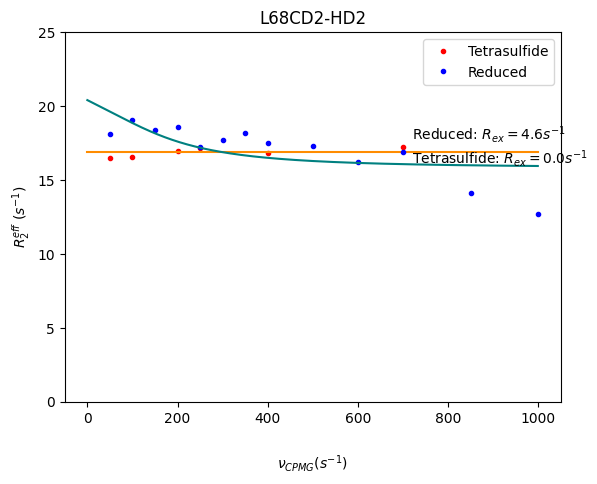

/tmp/ipykernel_11059/362722824.py:17: RuntimeWarning: divide by zero encountered in divide
  return R2+Rex*(1-2*t*nu*np.tanh(1/(2*t*nu)))
/tmp/ipykernel_11059/362722824.py:17: RuntimeWarning: divide by zero encountered in divide
  return R2+Rex*(1-2*t*nu*np.tanh(1/(2*t*nu)))
/tmp/ipykernel_11059/362722824.py:17: RuntimeWarning: divide by zero encountered in divide
  return R2+Rex*(1-2*t*nu*np.tanh(1/(2*t*nu)))
/tmp/ipykernel_11059/362722824.py:17: RuntimeWarning: divide by zero encountered in divide
  return R2+Rex*(1-2*t*nu*np.tanh(1/(2*t*nu)))
/tmp/ipykernel_11059/362722824.py:17: RuntimeWarning: divide by zero encountered in divide
  return R2+Rex*(1-2*t*nu*np.tanh(1/(2*t*nu)))
/tmp/ipykernel_11059/362722824.py:17: RuntimeWarning: divide by zero encountered in divide
  return R2+Rex*(1-2*t*nu*np.tanh(1/(2*t*nu)))


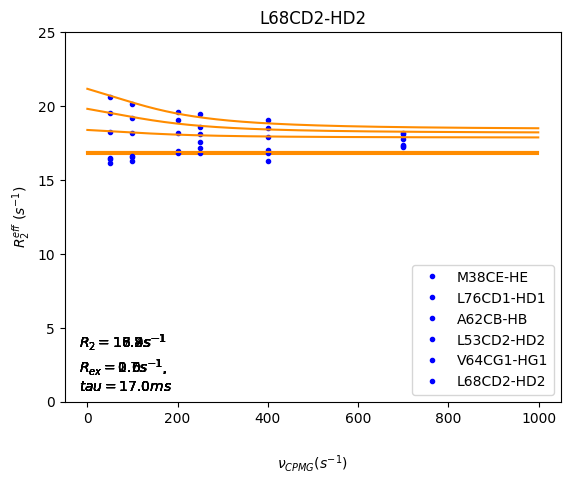

/tmp/ipykernel_11059/362722824.py:17: RuntimeWarning: divide by zero encountered in divide
  return R2+Rex*(1-2*t*nu*np.tanh(1/(2*t*nu)))


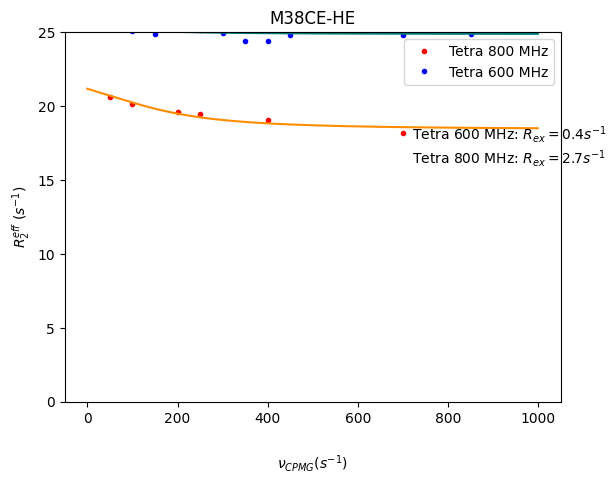

In [17]:
#Revisar ajustes:
# Redefine selected_plots locally to fix the KeyError.
def selected_plots(R2effs, all_fits, fixed_tau_plot, resnames = False, decay=True, barplot = False, compare_datasets = False, save = False ):
  if resnames == False:
    resnames = R2effs.index.values

  freqs = R2effs.columns.values
  combined_data = pd.concat([R2effs, all_fits], axis=1)

  if compare_datasets:
    R2effs_compare = compare_datasets[0]
    all_fits_compare = compare_datasets[1]
    names = compare_datasets[2]
    freqs_compare = R2effs_compare.columns.values
    combined_data_compare = pd.concat([R2effs_compare, all_fits_compare], axis=1)
  plt.figure()
  for resname in resnames:
    R2efflist = combined_data[freqs].loc[resname].values
    R2_val = combined_data['R2'].loc[resname]
    R2_err_val = combined_data['R2_err'].loc[resname]
    Rex_val = combined_data['Rex'].loc[resname]
    Rex_err_val = combined_data['Rex_err'].loc[resname]
    # Use fixed_tau_plot for display if it's meant to be different, otherwise use the global fixed_tau
    Tau_ms = fixed_tau_plot * 1000 # This will use the value passed to selected_plots
    exp1 = r'$R_{2} = %.1f$' % R2_val + r'$s^{-1}$'
    exp2 = r'$R_{ex} = %.1f$' % Rex_val + r'$s^{-1}$'
    exp2 = r'$R_{ex} = %.1f$' % Rex_val + r'$s^{-1}$'
    exp3 = r'$tau = %.1f ms$' % Tau_ms

    if compare_datasets:
      R2efflist_compare = combined_data_compare[freqs_compare].loc[resname].values # FIX: Use freqs_compare
      R2_val_compare = combined_data_compare['R2'].loc[resname]
      R2_err_val_compare = combined_data_compare['R2_err'].loc[resname]
      Rex_val_compare = combined_data_compare['Rex'].loc[resname]
      Rex_err_val = combined_data_compare['Rex_err'].loc[resname]
      exp2_compare = r'$R_{ex} = %.1f$' % Rex_val_compare + r'$s^{-1}$'

    if decay:
        y = R2efflist
        x = freqs
        if compare_datasets:
          y_compare = R2efflist_compare
          x_compare = freqs_compare


        if compare_datasets:
          plt.plot(x_compare,y_compare,'r.', label= names[1])
          # fitFunc still uses the global fixed_tau, consider this if plotting fixed_tau_plot was the intent
          plt.plot(np.arange(0,1000,1), fitFunc(np.arange(0,1000,1),R2_val_compare, Rex_val_compare),'darkorange')
          plt.plot(x,y,'b.', label=names[0])
          plt.plot(np.arange(0,1000,1), fitFunc(np.arange(0,1000,1),R2_val, Rex_val),'teal')
        else:
          plt.plot(x,y,'b.', label=resname)
          plt.plot(np.arange(0,1000,1), fitFunc(np.arange(0,1000,1),R2_val, Rex_val),'darkorange')

        plt.ylabel('$R_2^{eff}$' + ' ($s^{-1}$)')
        plt.xlabel(r'$\nu_{CPMG}$' + r'($s^{-1}$)', labelpad=20)
        if compare_datasets:
          plt.annotate(names[0] + ': ' + exp2 + '\n' + names[1] + ': ' + exp2_compare, xy=(250, 200), xycoords='axes points', horizontalalignment='left', verticalalignment='top')
        else:
          plt.annotate(exp1 + '\n' + exp2 + ',' + '\n' + exp3, xy=(10, 50), xycoords='axes points', horizontalalignment='left', verticalalignment='top')
        plt.legend()
        if save:
          plt.savefig(resname + '.svg', format='svg', bbox_inches='tight')

        plt.title(resname)
  plt.ylim(0,25)
  plt.show()
  if barplot:
      R2_val = combined_data['R2'].loc[resnames]
      R2_err_val = combined_data['R2_err'].loc[resnames]
      Rex_val = combined_data['Rex'].loc[resnames]
      Rex_err_val = combined_data['Rex_err'].loc[resnames]
      plt.figure()
      plt.bar(resnames, Rex_val, yerr=Rex_err_val,error_kw=dict(ecolor='black', capsize=5, elinewidth=1.5), color='red')
      plt.xticks(resnames, ha='right', rotation=45)
      plt.ylabel('$R_{ex}$' + ' ($s^{-1}$)')

residuos = ['M38CE-HE','L76CD1-HD1','A62CB-HB','L53CD2-HD2','V64CG1-HG1','L68CD2-HD2']
print(' - ' * 30 )

selected_plots(R2effs_800_red,all_fits_800_red,fixed_tau_plot=0.017,
               resnames = [residuos[-1]],
               decay=True, compare_datasets = [R2effs_800_tetra,all_fits_800_tetra, ['Reduced','Tetrasulfide']],
               save = True)
selected_plots(R2effs_800_tetra,all_fits_800_tetra,fixed_tau_plot=0.017,
               resnames = residuos,
               decay=True, compare_datasets = False,
               save = True)

selected_plots(R2effs_600_tetra,all_fits_600_tetra,fixed_tau_plot=0.017,
               resnames = ['M38CE-HE'],
               decay=True, compare_datasets = [R2effs_800_tetra, all_fits_800_tetra, ['Tetra 600 MHz', 'Tetra 800 MHz']],
               save = False)

#print(' Red ')
#plot_raw_signal(DF_800_red, residuo)
#print(' - ' * 30 )
#print(' Tetra ')
#plot_raw_signal(DF_800_tetra, residuo)

In [31]:
def fitCurvesFreeTau(R2effs):
    assignments = R2effs.index
    all_fits_free_tau = pd.DataFrame(columns=['t', 't_err', 'R2','R2_err','Rex','Rex_err'],index=assignments)

    # Initial guesses for t, R2, Rex.
    # t is in seconds (initial guess from fixed_tau), R2/Rex in Hz
    initial_guess = [0.0017, 10.0, 1.0] # t, R2, Rex

    # Bounds for t, R2, Rex
    lower_bounds = [0.0005, 0.0, 0.0] # t (s), R2 (Hz), Rex (Hz)
    upper_bounds = [0.0020, 100.0, 100.0] # t (s), R2 (Hz), Rex (Hz)

    for ass in assignments:
        R2eff_row = R2effs.loc[ass] # This is a pandas Series

        # Filter out non-finite (NaN, inf, -inf) values from R2eff_row
        R2eff_row_filtered_series = R2eff_row[np.isfinite(R2eff_row)]

        R2efflist_filtered = R2eff_row_filtered_series.values
        freqs_filtered = R2eff_row_filtered_series.index.values # Get frequencies directly from the filtered series

        # curve_fit needs at least as many data points as parameters (3 here: t, R2, Rex)
        if len(R2efflist_filtered) < 3:
            print(f"Warning: Not enough valid data points for assignment '{ass}' after filtering non-finite values. Skipping fit for free tau.")
            all_fits_free_tau.loc[ass] = [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]
            continue

        try:
            # fitFreeTau takes (nu, t, R2, Rex)
            fitParams, fitCovariances = curve_fit(fitFreeTau, freqs_filtered, R2efflist_filtered,
                                                  p0=initial_guess,
                                                  bounds=(lower_bounds, upper_bounds))
            t_fit, R2_fit, Rex_fit = fitParams
            perr = np.sqrt(np.diag(fitCovariances))
            t_err, R2_err, Rex_err = perr
            all_fits_free_tau.loc[ass]=[t_fit, t_err, R2_fit, R2_err, Rex_fit, Rex_err]
        except RuntimeError as e:
            print(f"Warning: Could not fit curve for assignment '{ass}' with free tau. Error: {e}")
            all_fits_free_tau.loc[ass] = [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]
        except ValueError as e:
            print(f"Warning: ValueError during fit for assignment '{ass}' with free tau. Error: {e}")
            all_fits_free_tau.loc[ass] = [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]
    return all_fits_free_tau

# Apply the new fitting function to all R2eff dataframes
all_fits_600_red_free_tau = fitCurvesFreeTau(R2effs_600_red)
all_fits_600_tetra_free_tau = fitCurvesFreeTau(R2effs_600_tetra)
all_fits_800_red_free_tau = fitCurvesFreeTau(R2effs_800_red)
all_fits_800_tetra_free_tau = fitCurvesFreeTau(R2effs_800_tetra)

print("Fitting with free tau complete. Results stored in 'all_fits_..._free_tau' dataframes.")

Fitting with free tau complete. Results stored in 'all_fits_..._free_tau' dataframes.


In [32]:
def plotCurvesFreeTau(R2effs, all_fits_free_tau):
    freqs = R2effs.columns.values # Frequencies are common for all plots

    # Concatenate R2effs and all_fits_free_tau to iterate over each peak (row) individually
    # This handles duplicate assignment names by treating each row as a distinct entry.
    combined_data = pd.concat([R2effs, all_fits_free_tau], axis=1)

    rows_per_page = 5
    cols_per_page = 4
    num_plots_per_page = rows_per_page * cols_per_page

    num_total_plots = len(combined_data)
    pages = ceil(num_total_plots / num_plots_per_page)

    fig = None
    axes = None
    row_idx = 0
    col_idx = 0
    page_num = 0

    for idx, (original_assignment, row_series) in enumerate(combined_data.iterrows()):
        # Initialize new figure/axes for a new page if necessary
        if idx % num_plots_per_page == 0:
            if fig is not None: # Save previous page if it exists
                big_ax = fig.add_subplot(111)
                big_ax.set_facecolor("none")
                big_ax.tick_params(labelcolor='none', top='off', bottom='off', left='off', right='off')
                big_ax.spines['top'].set_color('none')
                big_ax.spines['bottom'].set_color('none')
                big_ax.spines['left'].set_color('none')
                big_ax.spines['right'].set_color('none')
                big_ax.set_title(sample_name)
                plt.ylabel('$R2_{eff}$' + ' (Hz)')
                plt.xlabel(r'$\nu_{cp}$ (Hz)', labelpad=20)
                plt.savefig('%s_curves_freetau_%d.pdf' % (sample_name, page_num))
                plt.show()

            fig, axes = plt.subplots(rows_per_page, cols_per_page, sharex=True, sharey=True)
            fig.set_size_inches(18, 19.5)
            fig.subplots_adjust(wspace=0.1, hspace=0.1)
            row_idx = 0
            col_idx = 0
            page_num = idx // num_plots_per_page

        # Extract data for the current peak
        ass = original_assignment # The assignment string for this specific peak

        # R2eff values are the columns corresponding to frequencies
        R2efflist = row_series[freqs].values.tolist()

        # Fit parameters are the remaining columns, including 't'
        t_val, t_err_val, R2_val, R2_err_val, Rex_val, Rex_err_val = row_series[['t', 't_err', 'R2', 'R2_err', 'Rex', 'Rex_err']].values

        # Ensure R2, Rex, and t are floats for formatting, handling potential non-numeric values
        try:
            t = float(t_val)
        except (ValueError, TypeError):
            t = np.nan
        try:
            R2 = float(R2_val)
        except (ValueError, TypeError):
            R2 = np.nan
        try:
            Rex = float(Rex_val)
        except (ValueError, TypeError):
            Rex = np.nan

        Tau_ms = t * 1000 # Use the fitted 't' value
        exp1 = r'$R_{2} = %.1f$' % R2 + ' Hz'
        exp2 = r'$R_{ex} = %.1f$' % Rex + ' Hz'
        exp3 = r'$\tau = %.1f ms$' % Tau_ms # Display the fitted tau

        ax = axes[row_idx, col_idx]
        ax.plot(freqs, R2efflist, '.')
        # Only plot fit if t, R2 and Rex are not NaN
        if not (pd.isna(t) or pd.isna(R2) or pd.isna(Rex)):
            ax.plot(freqs, fitFreeTau(freqs, t, R2, Rex)) # Use fitFreeTau with individual t

        ax.axis(ymax=50)
        ax.axis(ymin=0)
        plt.setp(ax.get_xticklabels(), rotation='vertical')
        ax.annotate(ass + ',' + exp1 + '\n' + exp2 + ',' + exp3, xy=(10, 50), xycoords='axes points',
                    horizontalalignment='left', verticalalignment='top')

        col_idx += 1
        if col_idx >= cols_per_page:
            col_idx = 0
            row_idx += 1

    # After the loop, save the last page if it has any plots
    if fig is not None:
        # Fill remaining subplots on the last page with blanks
        while row_idx < rows_per_page:
            while col_idx < cols_per_page:
                axes[row_idx, col_idx].set_visible(False)
                col_idx += 1
            col_idx = 0
            row_idx += 1

        big_ax = fig.add_subplot(111)
        big_ax.set_facecolor('none')
        big_ax.tick_params(labelcolor='none', top='off', bottom='off', left='off', right='off')
        big_ax.spines['top'].set_color('none')
        big_ax.spines['bottom'].set_color('none')
        big_ax.spines['left'].set_color('none')
        big_ax.spines['right'].set_color('none')
        big_ax.set_title(sample_name)
        plt.ylabel('$R2_{eff}$' + ' (Hz)')
        plt.xlabel(r'$\nu_{cp}$ (Hz)', labelpad=20)
        plt.savefig('%s_curves_freetau_%d.pdf' % (sample_name, page_num))
        plt.show()

print("plotCurvesFreeTau function defined.")

plotCurvesFreeTau function defined.


Plotting curves with individual 't' values for 800 MHz Reduced dataset:


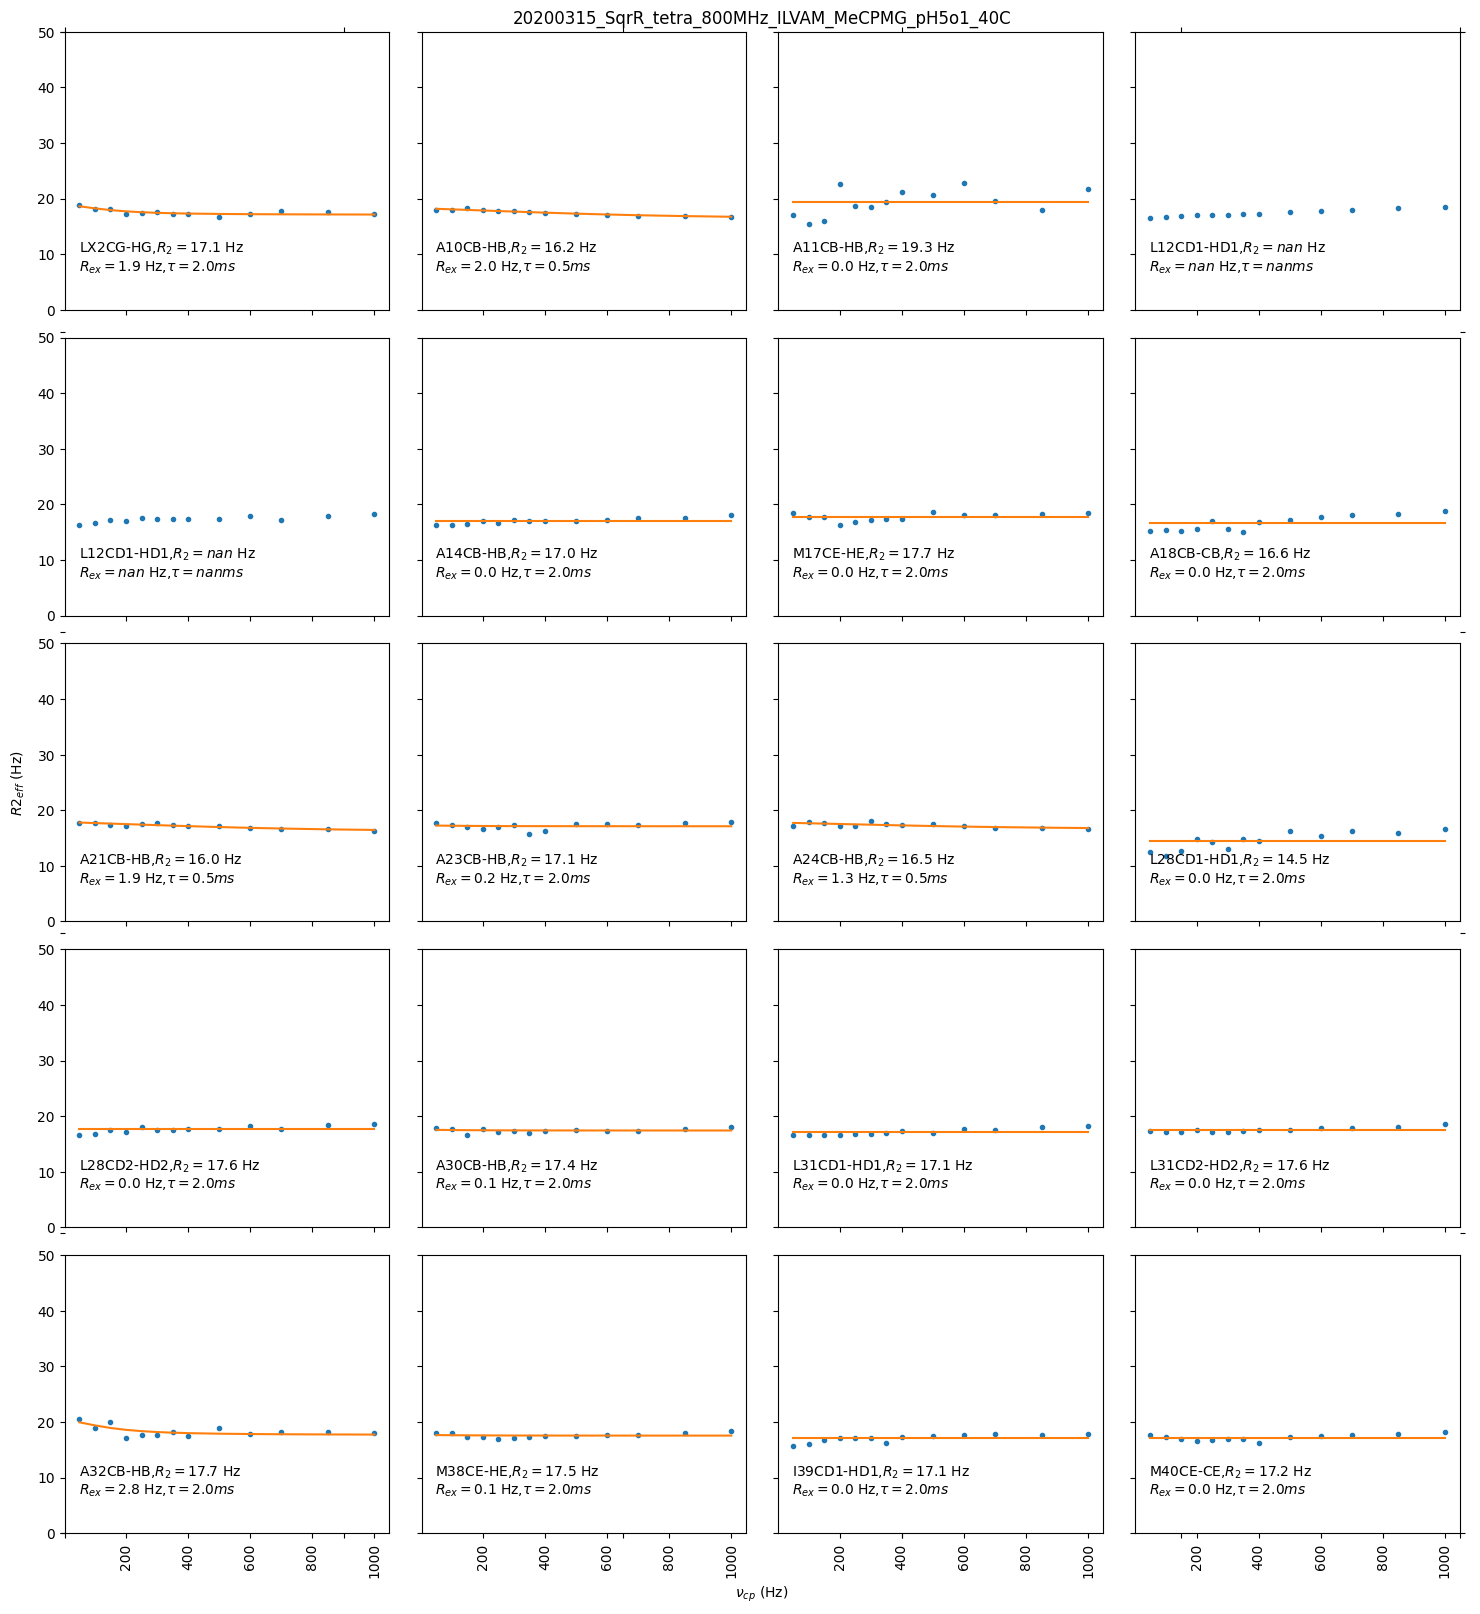

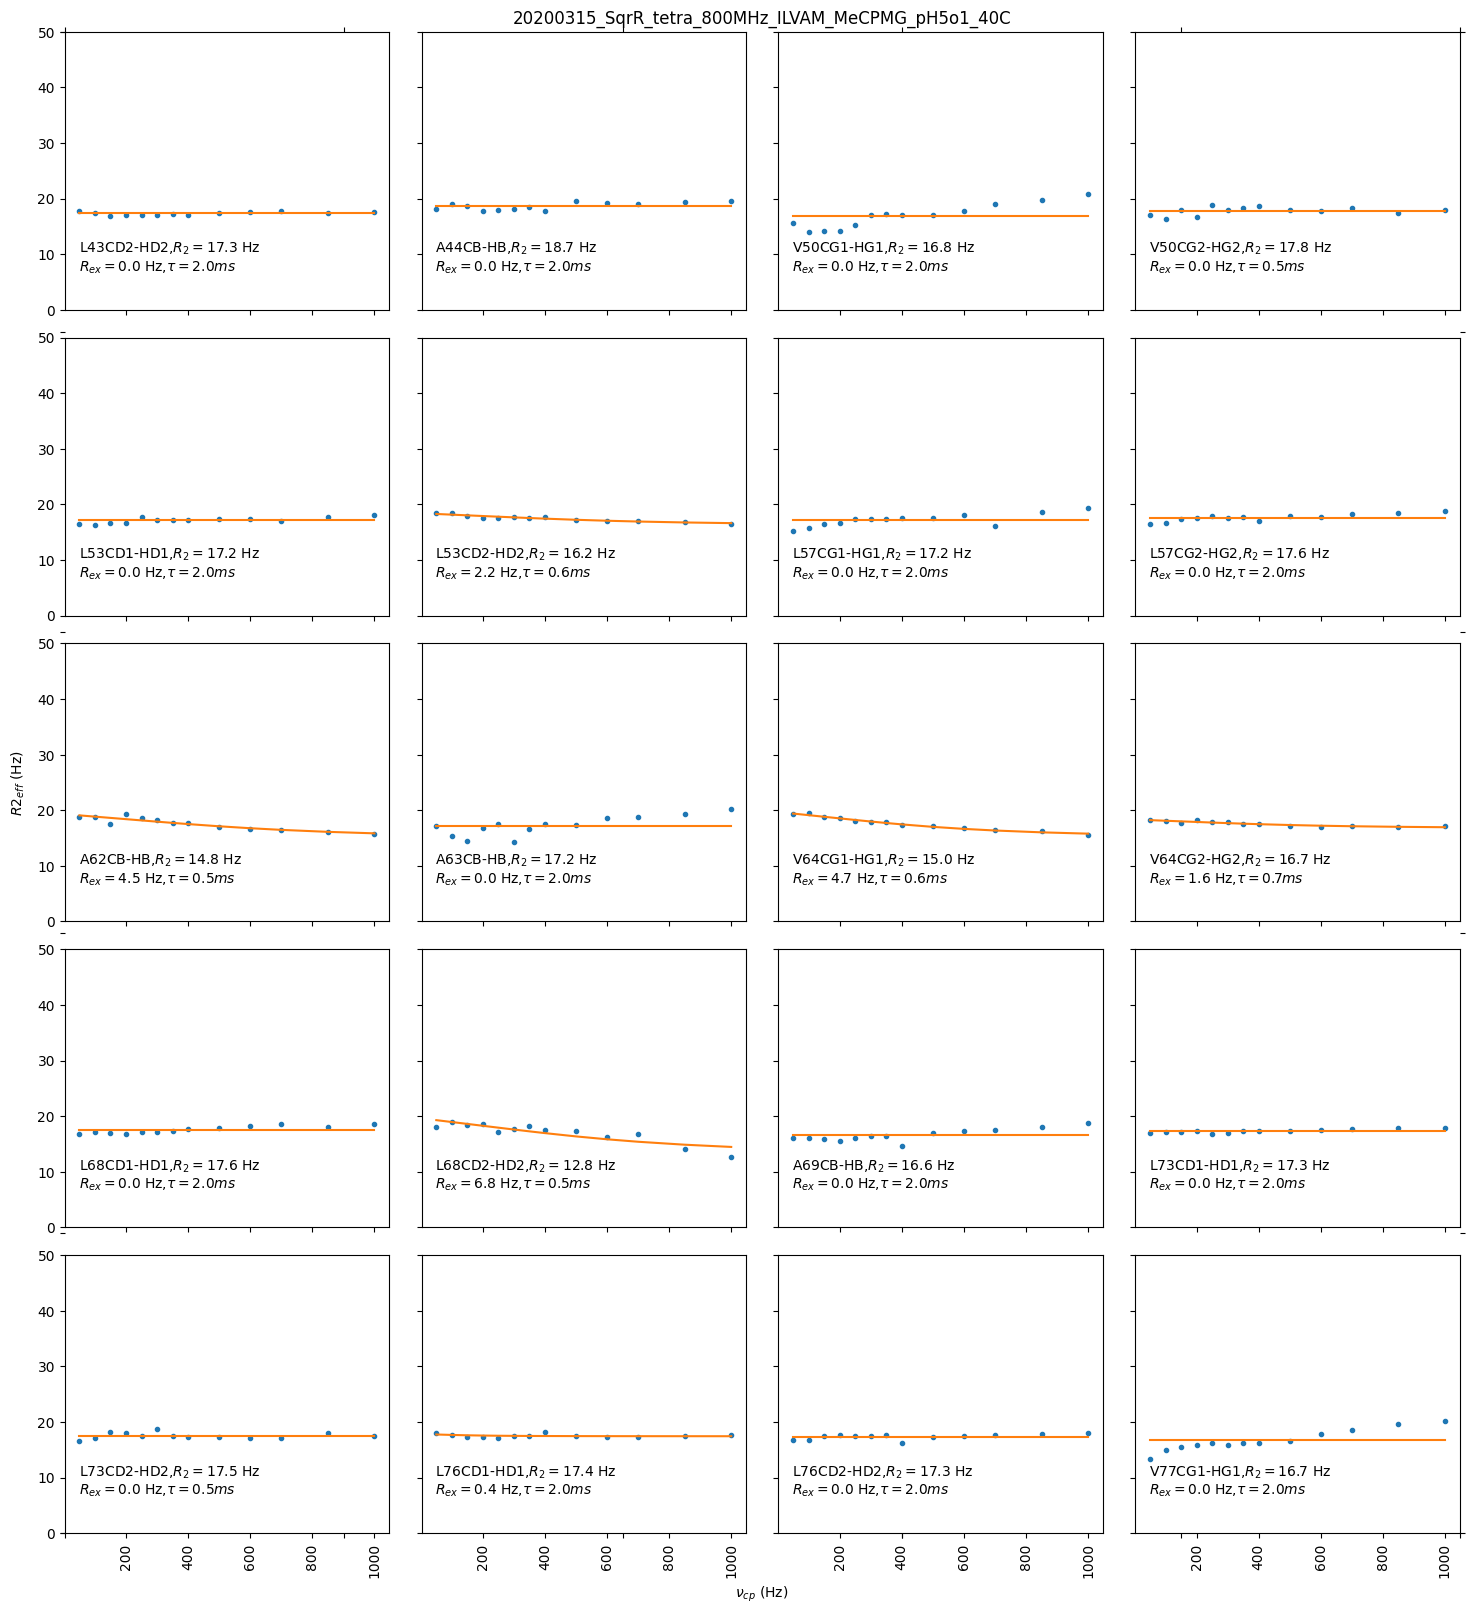

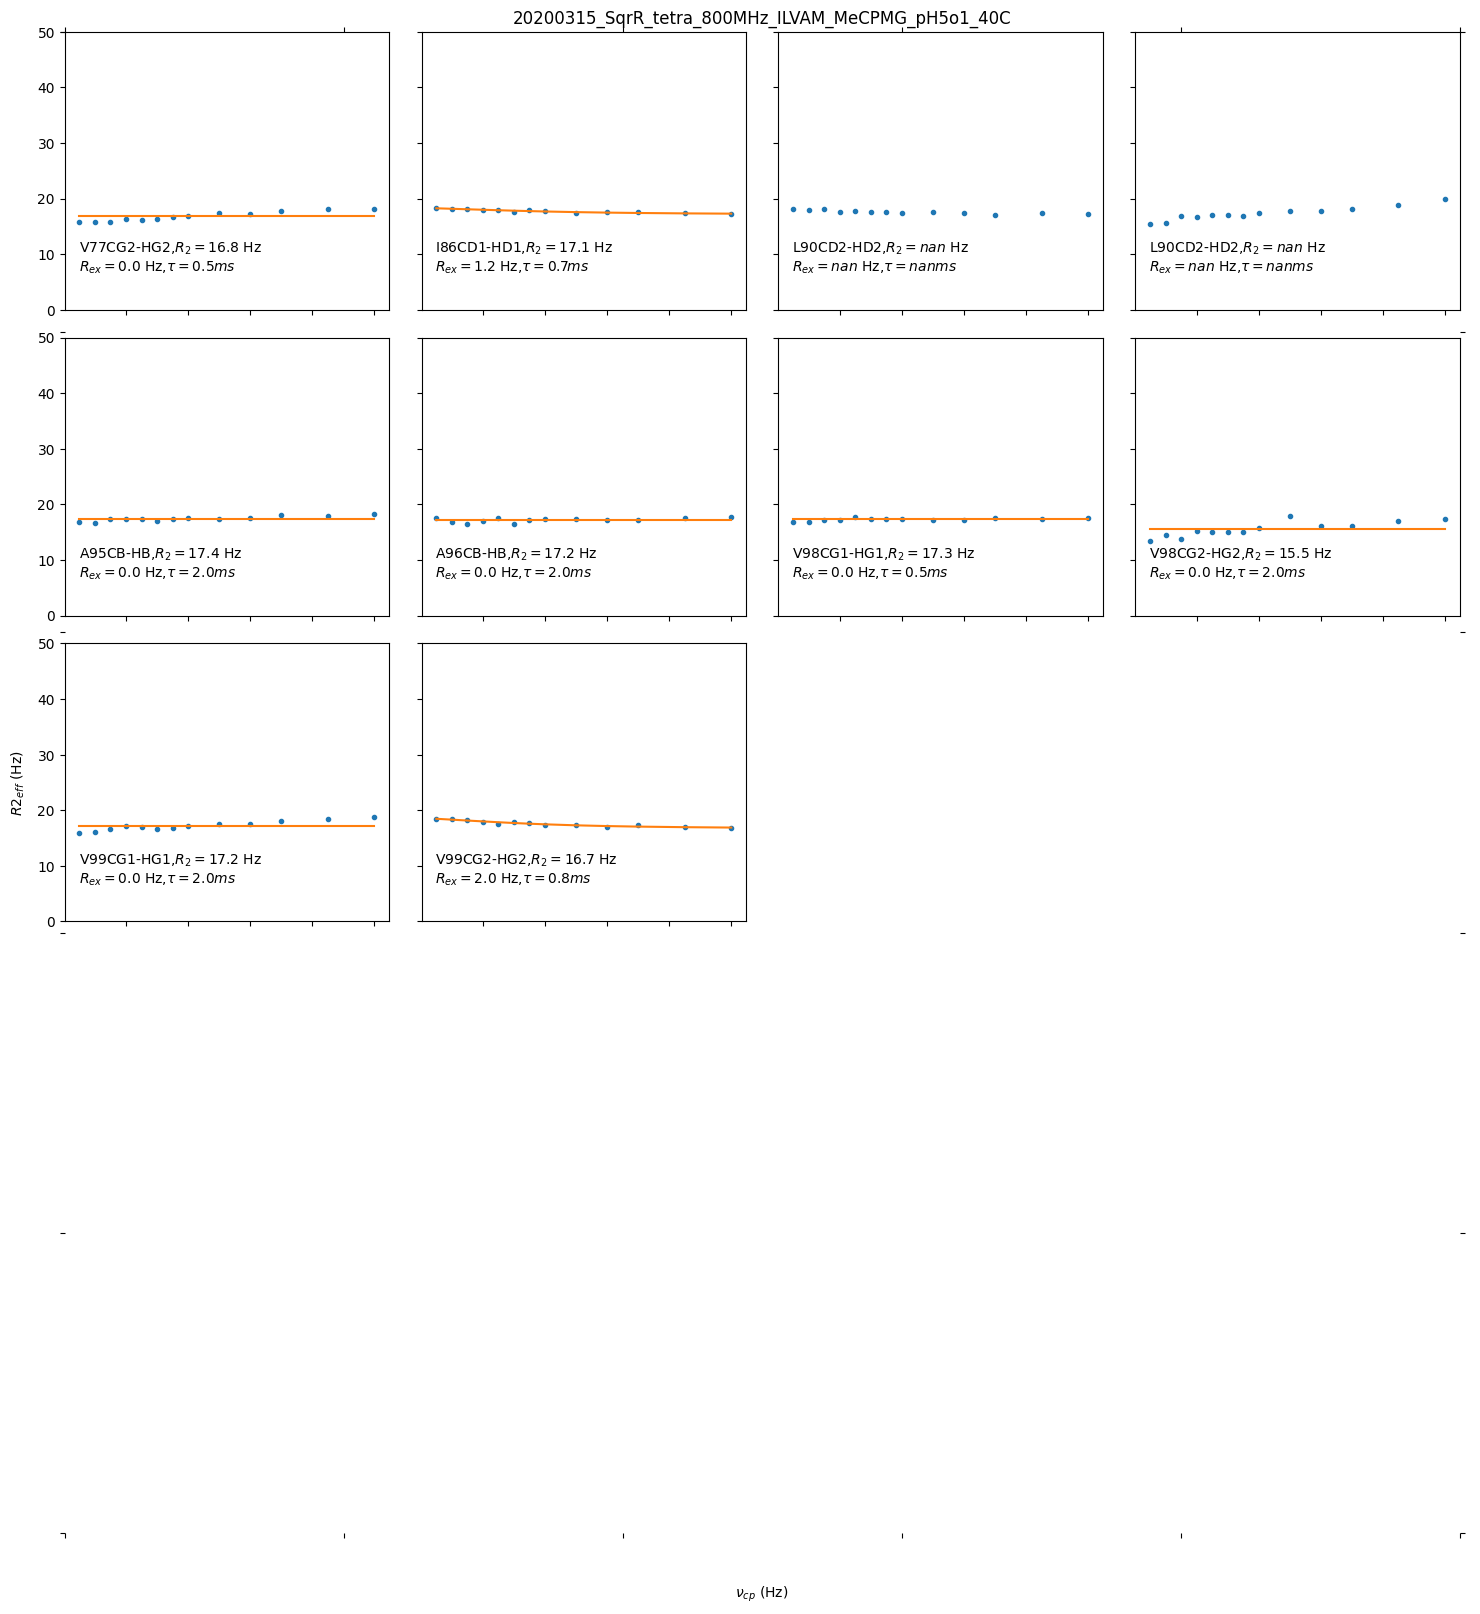

In [33]:
print("Plotting curves with individual 't' values for 800 MHz Reduced dataset:")
plotCurvesFreeTau(R2effs_800_red, all_fits_800_red_free_tau)

Plotting distribution for 600 MHz Reduced dataset:


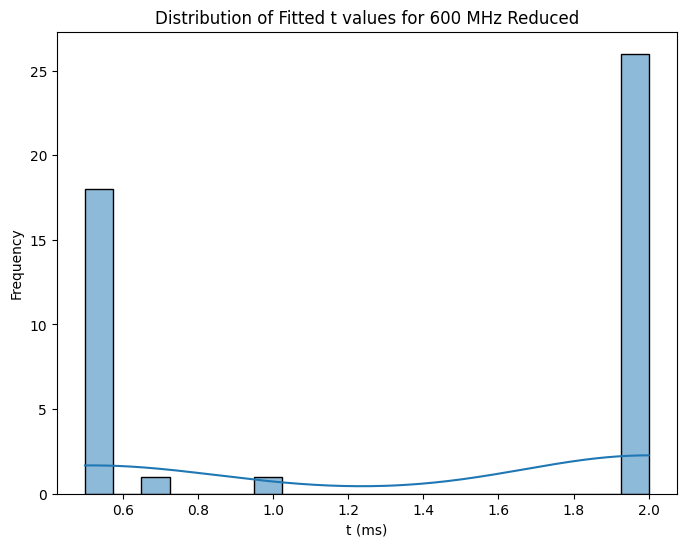


Plotting distribution for 600 MHz Tetra dataset:


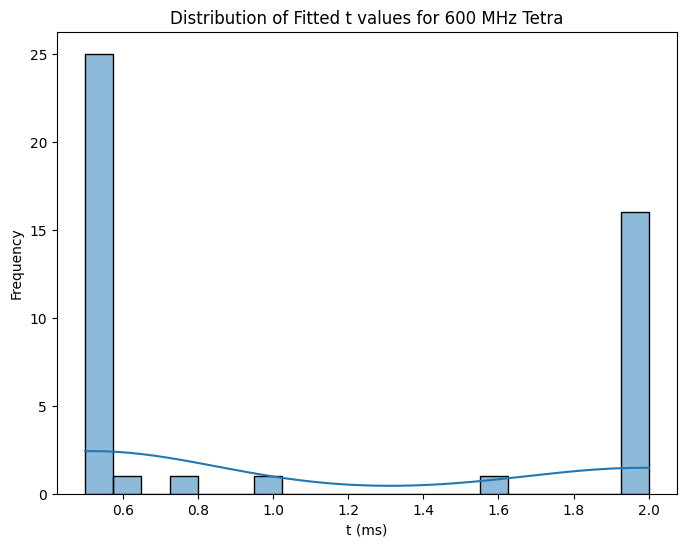


Plotting distribution for 800 MHz Reduced dataset:


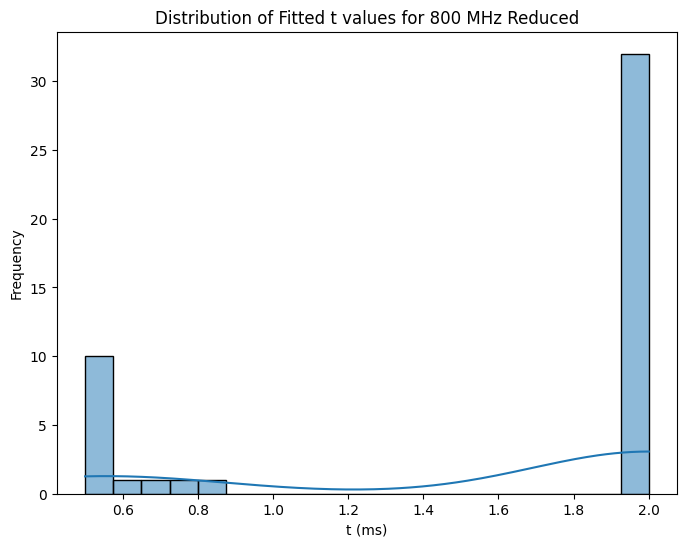


Plotting distribution for 800 MHz Tetra dataset:


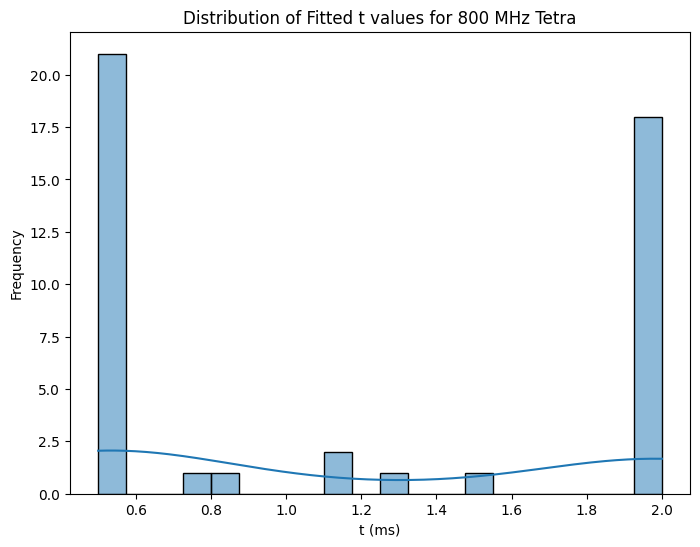

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_t_distribution(all_fits_free_tau_df, title_suffix):
    plt.figure(figsize=(8, 6))
    sns.histplot(all_fits_free_tau_df['t'].dropna()*1000, bins=20, kde=True)
    plt.title(f'Distribution of Fitted t values for {title_suffix}')
    plt.xlabel('t (ms)')
    plt.ylabel('Frequency')
    plt.show()

print("Plotting distribution for 600 MHz Reduced dataset:")
plot_t_distribution(all_fits_600_red_free_tau, '600 MHz Reduced')

print("\nPlotting distribution for 600 MHz Tetra dataset:")
plot_t_distribution(all_fits_600_tetra_free_tau, '600 MHz Tetra')

print("\nPlotting distribution for 800 MHz Reduced dataset:")
plot_t_distribution(all_fits_800_red_free_tau, '800 MHz Reduced')

print("\nPlotting distribution for 800 MHz Tetra dataset:")
plot_t_distribution(all_fits_800_tetra_free_tau, '800 MHz Tetra')



Plotting Rex values for all residues from specific datasets:


/tmp/ipykernel_11059/159504906.py:144: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  source_df_filtered.dropna(subset=['Rex'], inplace=True)
/tmp/ipykernel_11059/159504906.py:171: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  source_df_filtered['x_coord'] = source_df_filtered['Assignment'].map(assignment_to_x_coord)


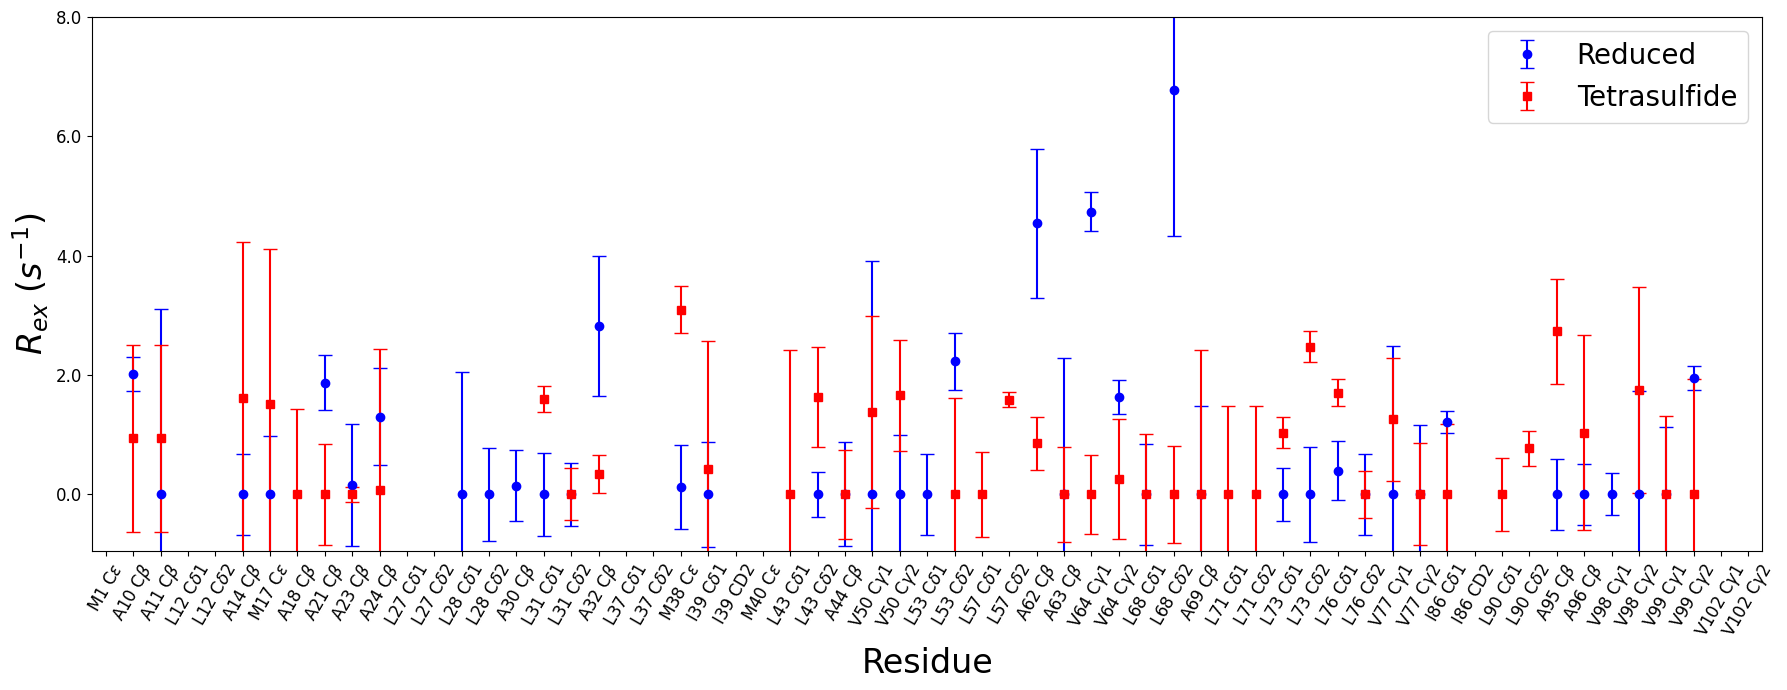


Plotting Rex values for selected residues from specific datasets:


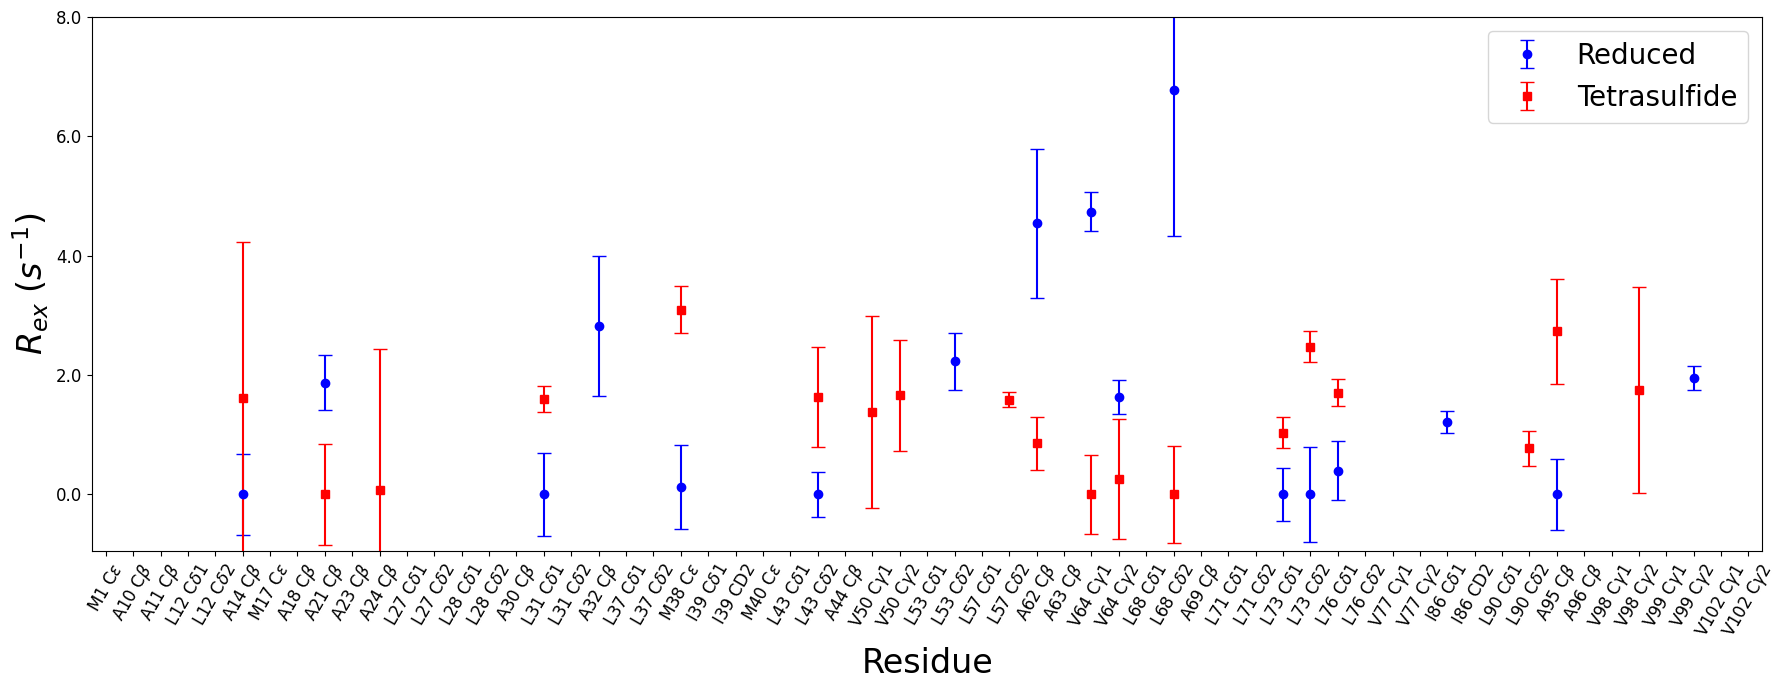

In [37]:
selected_resnames_dict_for_plot = {
    '800_red': ['A14CB-HB','A21CB-HB','A24CB-HB' 'A30CB-HB', 'L31CD1-HD1', 'A32CB-HB','M38CE-HE','L43CD2-HD2','L53CD2-HD2','A62CB-HB',
                'V64CG1-HG1','V64CG2-HG2','L68CD2-HD2', 'L73CD1-HD1', 'L73CD2-HD2','L76CD1-HD1','I86CD1-HD1', 'A95CB-HB','V99CG2-HG2'],
    '800_tetra': ['A14CB-HB','A21CB-HB','A24CB-HB','A14CB-HB', 'A30CB-HB',
                  'L31CD1-HD1','M38CE-HE','L43CD2-HD2','V50CG1-HG1',
                  'V50CG2-HG2','L57CD2-HD2', 'A62CB-HB','V64CG1-HG1','V64CG2-HG2', 'L68CD2-HD2', 'L73CD1-HD1',
                  'L73CD2-HD2', 'L76CD1-HD1', 'L90CD2-HD2', 'A95CB-HB', 'V98CG2-HG2']
}

plot_all_fits_dataframes = {
    '800_red': all_fits_800_red_free_tau,
    '800_tetra': all_fits_800_tetra_free_tau
}


print("\nPlotting Rex values for all residues from specific datasets:")
multi_Rex_scatterplot(plot_all_fits_dataframes, selected_resnames_dict=None,
                      set_colors = ['blue', 'red'],
                      save=True,
                      labels=['Reduced','Tetrasulfide'],
                      x_axis_labels= 'MGSDTDERSAALDAEEMATRARAASNLLKALAHEGRLMIMCYLASGEKSVTELETRLSTRQAAVSQQLARLRLEGLVQSRREGKTIYYSLSDPRAARVVQTVYEQFCSGD')

print("\nPlotting Rex values for selected residues from specific datasets:")
multi_Rex_scatterplot(plot_all_fits_dataframes, selected_resnames_dict=selected_resnames_dict_for_plot,
                      set_colors = ['blue', 'red'],
                      save=True,
                      labels=['Reduced','Tetrasulfide'],
                      x_axis_labels= 'MGSDTDERSAALDAEEMATRARAASNLLKALAHEGRLMIMCYLASGEKSVTELETRLSTRQAAVSQQLARLRLEGLVQSRREGKTIYYSLSDPRAARVVQTVYEQFCSGD')